# Modelado en WEAP: Datos Climáticos y Métodos de Interpolación para Cuencas Hidrográficas

### Caso de estudio: cuenca del Lago Titicaca (Perú – Bolivia), 1980–2020
---

La modelación hidrológica de una cuenca depende, en primer lugar, de la calidad y la representatividad de los datos climáticos que la alimentan. Las estaciones meteorológicas registran la precipitación y la temperatura en puntos aislados; sin embargo, un modelo como WEAP requiere conocer estas variables sobre toda la superficie de cada cuenca. Este cuaderno aborda ese paso intermedio: cómo transformar registros puntuales en campos espaciales continuos, qué métodos existen para hacerlo, cómo evaluarlos y cómo entregar el resultado en un formato que WEAP pueda utilizar directamente.

**Objetivo general**

Generar series mensuales espacialmente distribuidas de precipitación y temperatura en formato NetCDF, a partir de registros diarios de estaciones del SENAMHI, como insumo para la modelación hidrológica en WEAP.

**Objetivos específicos**

Al finalizar el módulo, usted estará en capacidad de:

1. Explicar por qué WEAP requiere datos climáticos espacializados y cómo los incorpora.
2. Describir los principales métodos de interpolación espacial, sus formulaciones y sus diferencias.
3. Aplicar la relación entre temperatura y altitud para interpolar la temperatura en zonas de montaña.
4. Evaluar y seleccionar métodos de interpolación mediante validación cruzada.
5. Generar e interpretar un archivo NetCDF con precipitación y temperatura mensuales.

## Estructura de la sesión

| Parte | Contenido |
|---|---|
| I | Datos climáticos en WEAP y caso de estudio |
| II | Fundamentos de la interpolación espacial |
| III | Métodos: Thiessen, IDW, spline, superficie de tendencia y kriging |
| IV | Temperatura y altitud |
| V | Evaluación y selección del método |
| VI | El formato NetCDF |
| VII | Ejercicio práctico: generación del NetCDF |
| VIII | Aplicación en WEAP y actividades |

**Datos:** precipitación diaria (85 estaciones) y temperatura media diaria (18 estaciones), 1980–2020, del SENAMHI del Perú y de Bolivia; DEM de 30″ (≈ 900 m) en WGS84 y límite de la cuenca. Estudio de referencia: MMAyA y SEI (2024), *Balance Hídrico de Bolivia 1980–2020*, https://doi.org/10.5281/zenodo.10850934

**Uso:** las Partes I a VI son de lectura. Para el ejercicio (Parte VII), seleccione *Entorno de ejecución → Ejecutar todas*; los datos se descargan automáticamente y los parámetros se modifican únicamente en el Paso 1 (👈).

# Parte I. Datos climáticos en WEAP

Los métodos de cuenca de WEAP (por ejemplo, humedad del suelo) requieren precipitación y temperatura, entre otras variables, para cada cuenca y paso de tiempo. El flujo de trabajo de esta sesión es:

**Estaciones (diario) → agregación mensual → interpolación con DEM → NetCDF → WEAP**

En el modo de **delimitación de cuencas** (*Catchment Delineation*), WEAP lee un NetCDF, calcula para cada banda de elevación el **promedio ponderado por área** de las celdas que la cubren, genera un CSV por cuenca y crea las expresiones `ReadFromFile`. Requisitos del archivo según la ayuda de WEAP:

| Requisito de WEAP | Archivo de este curso |
|---|---|
| Malla rectangular latitud-longitud que cubra todas las cuencas | WGS84, extensión completa del DEM |
| Variables con dimensiones *time, latitude, longitude*, en ese orden | `Pcp(time, lat, lon)`, `Ts(time, lat, lon)` |
| Nombres: `time`; `lat`/`latitude`/`Y`; `lon`/`longitude`/`X` | `time`, `lat`, `lon` |
| Paso diario o mensual; NetCDF versión 4 o anterior | Mensual; NetCDF clásico |

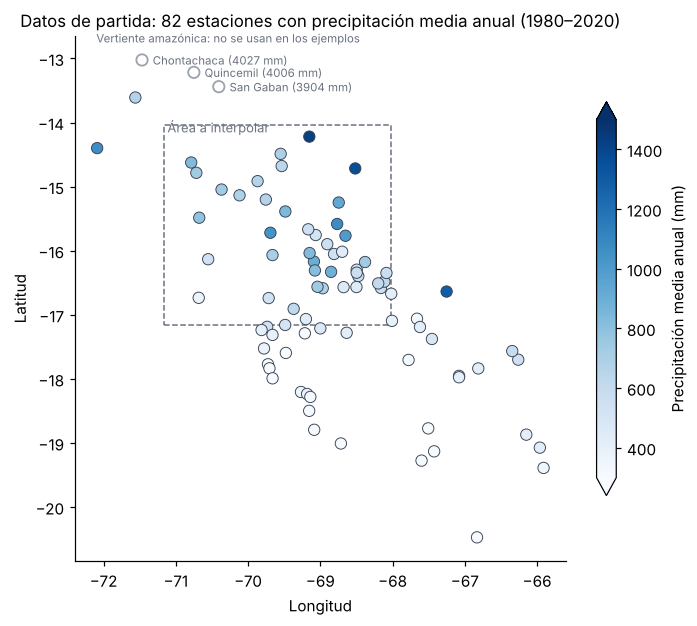

*Figura 1. Precipitación media anual (1980–2020) en las estaciones del caso de estudio; el recuadro es la extensión del DEM. Las tres estaciones de la vertiente amazónica se excluyen de los ejemplos de las Partes II a V.*

# Parte II. Fundamentos de la interpolación espacial

Interpolar consiste en estimar el valor en un punto sin medición, $x_0$, a partir de las observaciones $z(x_1), \dots, z(x_n)$. La mayoría de los métodos son un **promedio ponderado**:

$$\hat{z}(x_0) = \sum_{i=1}^{n} \lambda_i \, z(x_i)$$

**Los métodos difieren en cómo calculan los pesos $\lambda_i$:**

| Enfoque | Origen de los pesos | Métodos |
|---|---|---|
| Determinístico | Fórmula fija (distancia, suavidad) | Thiessen, IDW, spline, superficie de tendencia |
| Geoestadístico | Correlación espacial de los datos (semivariograma) | Kriging |
| Con covariables | Variable auxiliar conocida en toda el área (DEM) | Gradiente altitudinal, regresión |

Un método es **exacto** si reproduce el valor medido en cada estación (IDW, spline, kriging) y **suavizado** si no lo hace (superficie de tendencia).

# Parte III. Métodos de interpolación

## 3.1 Polígonos de Thiessen

Cada punto toma el valor de la estación más cercana. La precipitación media de la cuenca resulta:

$$\bar{P} = \sum_{i=1}^{n} \frac{A_i}{A}\, P_i$$

Es simple y sin parámetros, pero genera discontinuidades en los bordes de los polígonos.

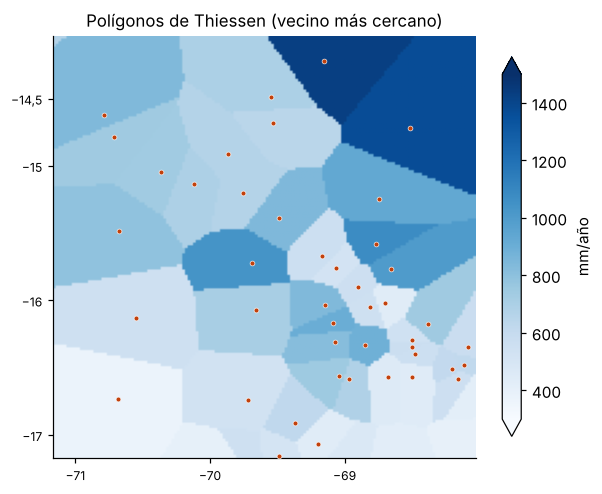

*Figura 2. Polígonos de Thiessen.*

## 3.2 Inverso de la distancia ponderada (IDW)

$$\hat{z}(x_0) = \frac{\sum_{i=1}^{n} w_i \, z_i}{\sum_{i=1}^{n} w_i}, \qquad w_i = \frac{1}{d_i^{\,p}}$$

Parámetros: potencia $p$ (usualmente 2) y número de vecinos $n$. En el ejemplo de la Figura 3, con $p = 2$ se obtiene 112,7 mm; con $p = 1$, 102,5 mm, y con Thiessen, 120 mm.

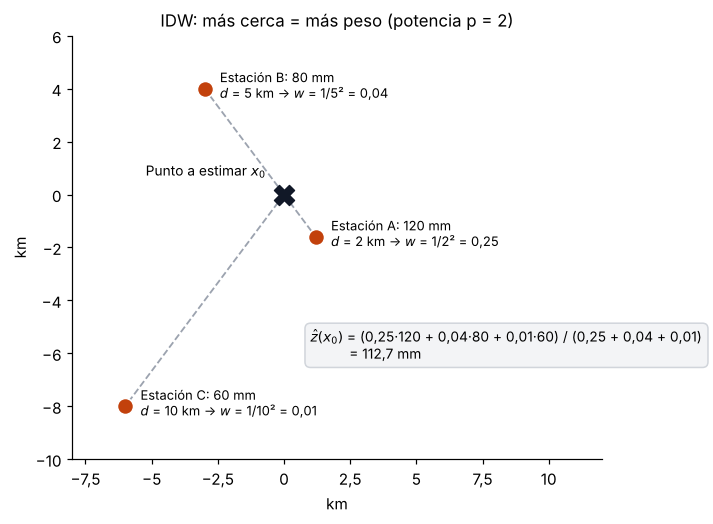

*Figura 3. Ejemplo numérico del IDW.*

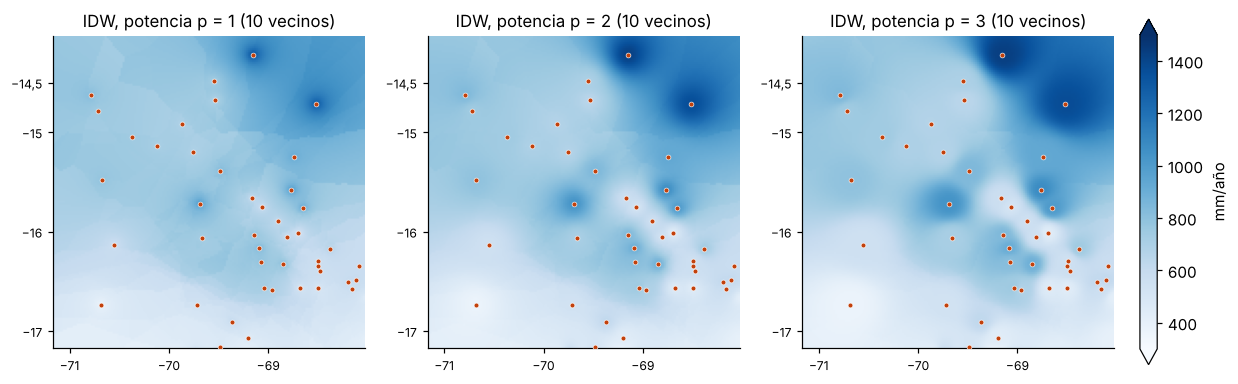

*Figura 4. Efecto de la potencia: a mayor $p$, mayor influencia local (efecto de "ojo de buey").*

El IDW es exacto, sus resultados siempre quedan dentro del rango observado (no genera valores negativos) y no requiere ajustar modelos; no incorpora el relieve. **Es el método aplicado a la precipitación en el ejercicio** ($p = 2$, $n = 10$, distancias geodésicas).

## 3.3 Spline de placa delgada

Superficie suave que pasa por los datos minimizando su curvatura:

$$\hat{z}(x, y) = a_0 + a_1 x + a_2 y + \sum_{i=1}^{n} \lambda_i \, r_i^2 \ln r_i$$

Produce mapas continuos, pero puede **sobrepasar** los valores observados: en la Figura 5 alcanza ≈ 2.200 mm en la esquina noreste, cuando la estación más lluviosa del área registra ≈ 1.430 mm. En meses secos puede generar precipitación negativa.

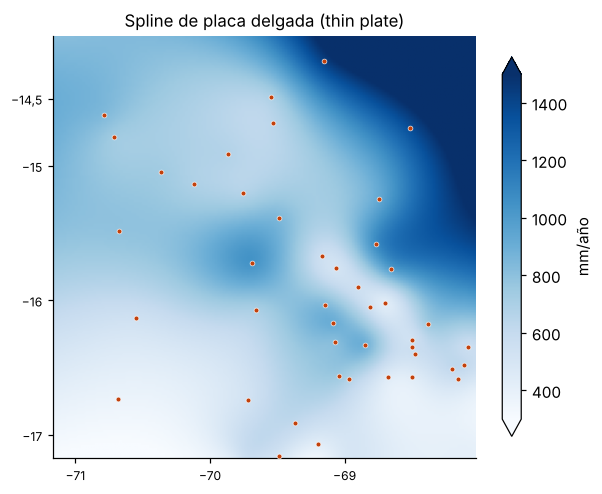

*Figura 5. Spline de placa delgada.*

## 3.4 Superficie de tendencia

Polinomio en las coordenadas ajustado por mínimos cuadrados (orden 1 y 2):

$$\hat{z} = \beta_0 + \beta_1 x + \beta_2 y \;\left(+\, \beta_3 x^2 + \beta_4 xy + \beta_5 y^2\right)$$

Representa el gradiente regional pero no el detalle local; se utiliza principalmente para remover la tendencia antes de interpolar los residuos.

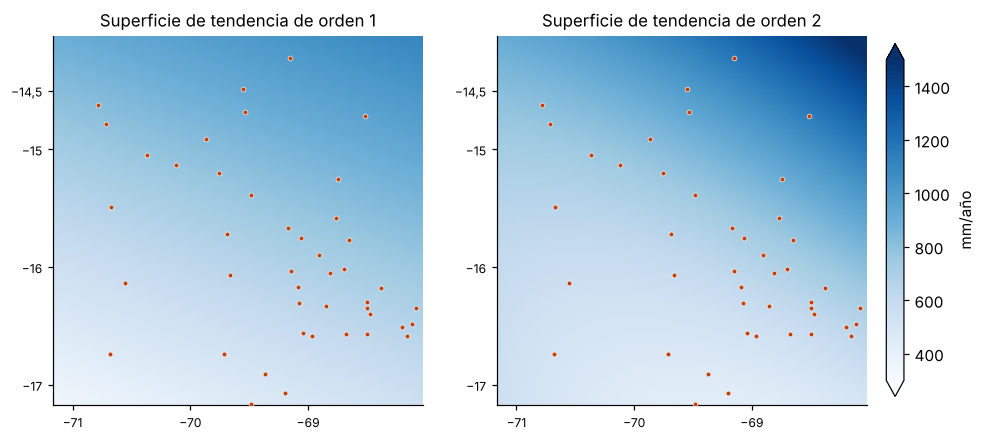

*Figura 6. Superficies de tendencia de orden 1 y 2.*

## 3.5 Kriging

Los pesos se obtienen de la correlación espacial de los datos, descrita por el **semivariograma**:

$$\hat{\gamma}(h) = \frac{1}{2N(h)} \sum_{i=1}^{N(h)} \left[ z(x_i) - z(x_i + h) \right]^2$$

Modelo esférico: $\gamma(h) = c_0 + c \left[ \frac{3h}{2a} - \frac{1}{2}\left(\frac{h}{a}\right)^3 \right]$ para $h \le a$, y $c_0 + c$ para $h > a$, donde $c_0$ es la pepita (*nugget*), $c_0 + c$ la meseta (*sill*) y $a$ el rango.

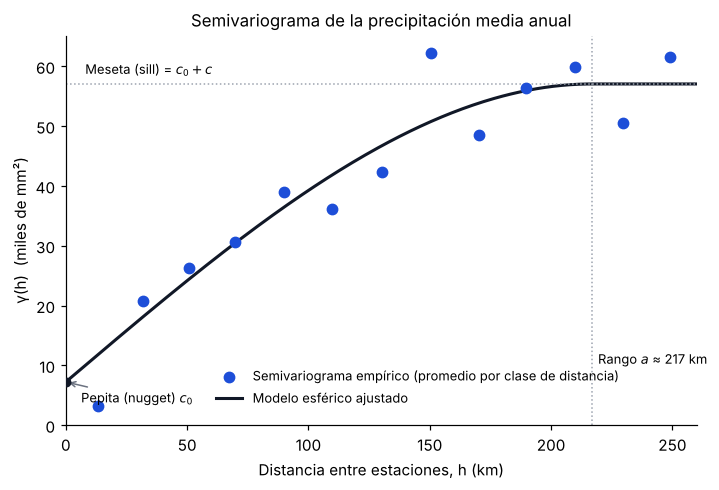

*Figura 7. Semivariograma de la precipitación media anual: correlación espacial hasta ≈ 220 km.*

**Kriging ordinario.** Los pesos minimizan la varianza del error con la condición de insesgamiento $\sum \lambda_i = 1$:

$$\sum_{j=1}^{n} \lambda_j \, \gamma(x_i, x_j) + \mu = \gamma(x_i, x_0), \quad i = 1, \dots, n \qquad\qquad \sigma_K^2(x_0) = \sum_{i=1}^{n} \lambda_i \, \gamma(x_i, x_0) + \mu$$

Su principal ventaja es el **mapa de incertidumbre** $\sigma_K$; requiere ajustar el semivariograma (idealmente con 30 o más estaciones), lo que en series mensuales implica un ajuste por mes. Variantes: kriging con deriva externa y cokriging, que incorporan el DEM u otras covariables.

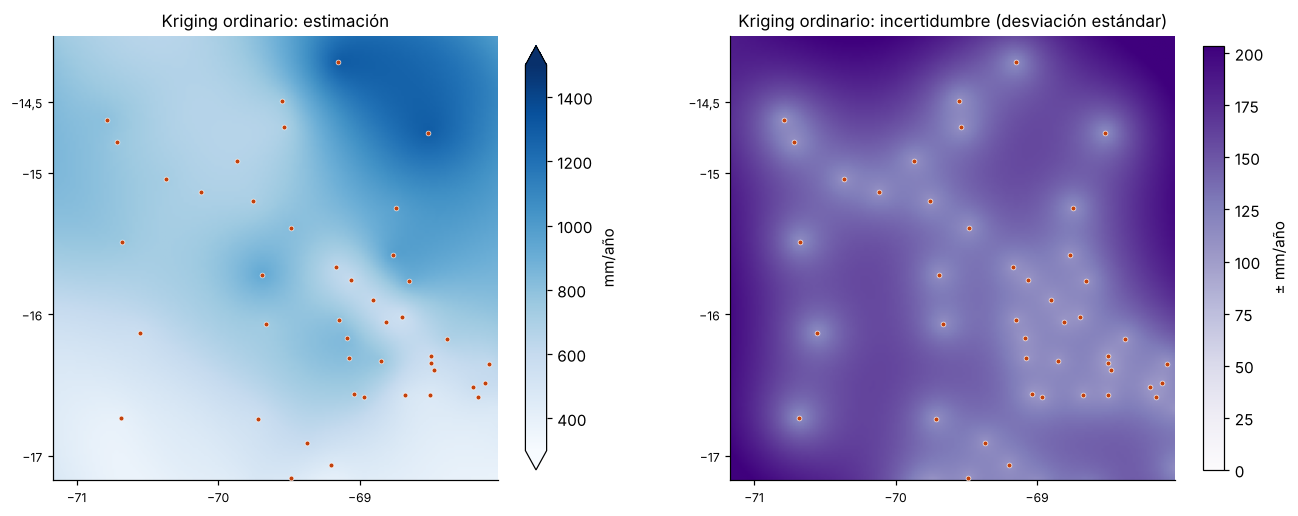

*Figura 8. Kriging ordinario: estimación e incertidumbre.*

# Parte IV. Temperatura y altitud

En zonas de montaña la temperatura depende principalmente de la altitud, por lo que debe interpolarse con el DEM.

**Gradiente altitudinal:** $\; T(z) = T_{ref} + \Gamma\,(z - z_{ref})$, con $\Gamma = -6{,}5\ ^\circ\text{C/km}$ en la atmósfera estándar. Para el Altiplano se han reportado gradientes más pronunciados, del orden de $-7{,}6\ ^\circ\text{C/km}$ (IRD, 1992); se recomienda contrastar el valor con datos locales.

**Regresión con la altitud:** $\; T_i = a + b\,z_i$, aplicada al DEM. Si las estaciones cubren un rango de altitud reducido, $b$ se sobreestima: en el caso de estudio (estaciones entre 3.715 y 4.360 m) resulta $b \approx -9{,}8\ ^\circ\text{C/km}$, lo que enfría en exceso las cumbres y calienta en exceso las zonas bajas.

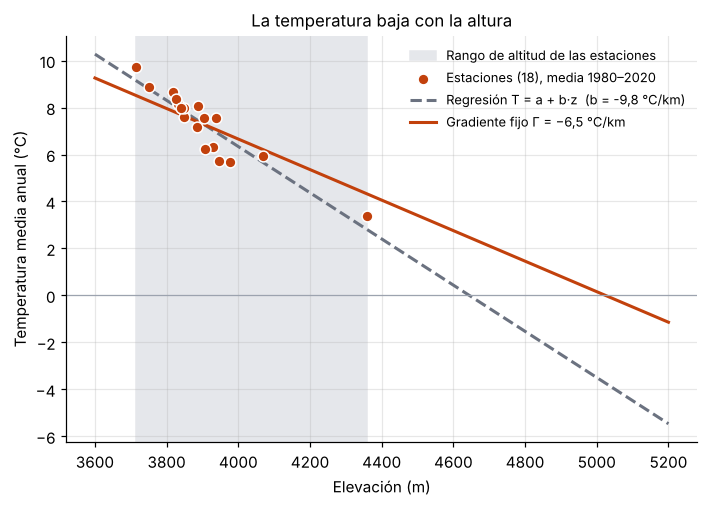

*Figura 9. Temperatura media de las estaciones frente a la altitud; la franja gris es el rango con observaciones.*

**Gradiente fijo con IDW (método del ejercicio).** Las estaciones se refieren al nivel del mar, se interpolan con IDW y se incorpora la altitud de cada celda:

$$T_{0,i} = T_i - \Gamma\, z_i \qquad\rightarrow\qquad \hat{T}_0(x_0) = \text{IDW}(T_{0,i}) \qquad\rightarrow\qquad \hat{T}(x_0) = \hat{T}_0(x_0) + \Gamma\, z_{DEM}(x_0)$$

Ejemplo con $\Gamma = -6{,}5\ ^\circ\text{C/km}$: una estación a 3.800 m con 8 °C da $T_0 = 32{,}7\ ^\circ\text{C}$, y una celda cercana a 4.800 m resulta en $32{,}7 - 31{,}2 = 1{,}5\ ^\circ\text{C}$.

> $T_0$ es un valor intermedio del cálculo, **no una temperatura real**: solo hace comparables las estaciones ubicadas a distintas altitudes.

El método pertenece a la familia de regresión con interpolación de residuos (*regression kriging* cuando el residuo se interpola con kriging):

$$\hat{T} = \underbrace{a + b\,z}_{\text{tendencia}} + \underbrace{\hat{\varepsilon}}_{\text{residuo}}$$

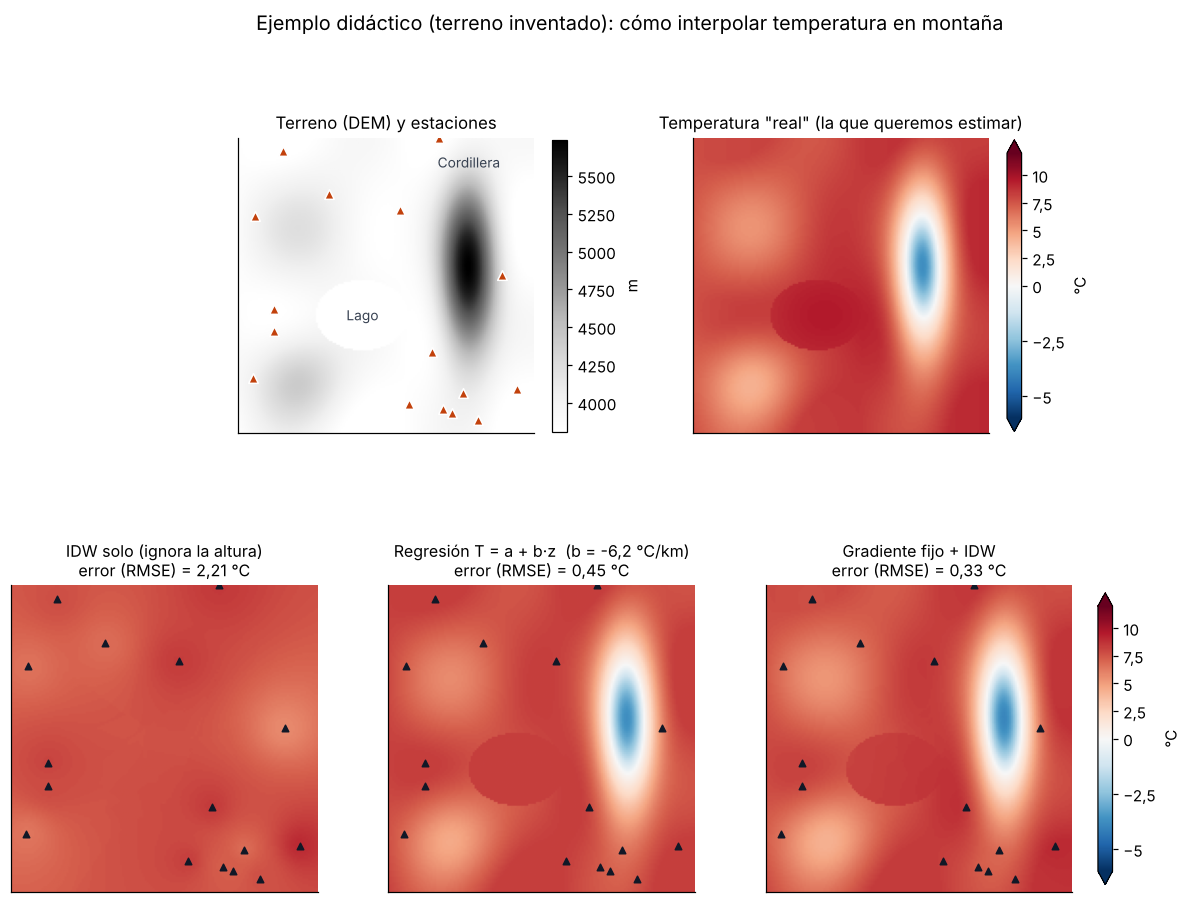

*Figura 10. Ejemplo con un terreno hipotético de temperatura conocida. El IDW sin altitud no reconoce la cordillera (error de 2,2 °C); el gradiente fijo con IDW es el más cercano a la realidad (error de 0,33 °C).*

# Parte V. Evaluación y selección del método

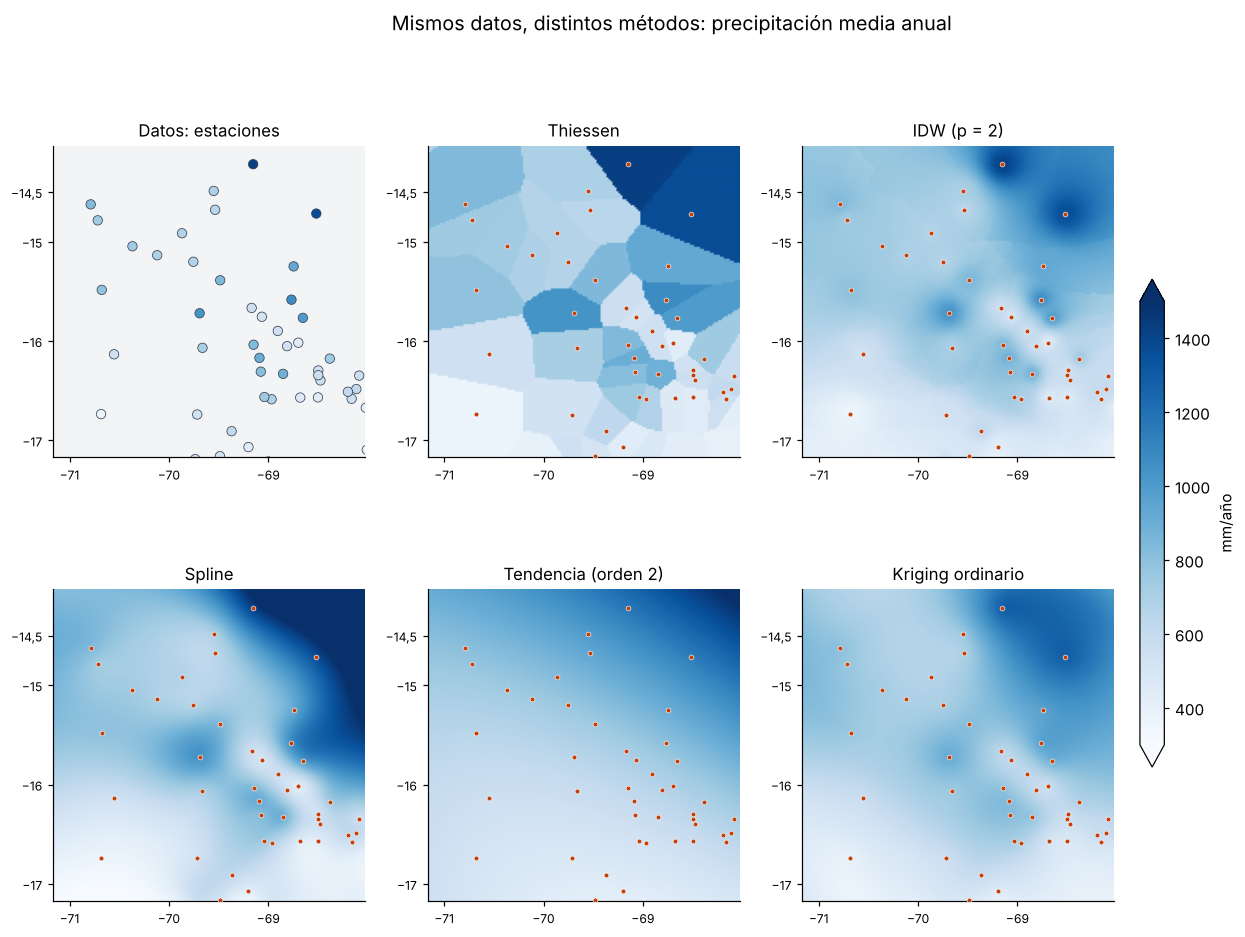

*Figura 11. Un mismo conjunto de datos interpolado con cinco métodos.*

| Método | Exacto | Usa DEM | Parámetros | Limitación principal | Aplicación |
|---|---|---|---|---|---|
| Thiessen | Sí | No | — | Discontinuidades | Precipitación media de cuenca |
| IDW | Sí | No | $p$, $n$ | "Ojo de buey" | Precipitación |
| Spline | Sí | No | Suavizado | Sobrepasa lo observado | Variables suaves |
| Tendencia | No | No | Orden | Pierde el detalle | Remoción de tendencia |
| Kriging | Sí | No* | Semivariograma | Ajuste más exigente | Redes densas, incertidumbre |
| Gradiente con IDW | Sí | Sí | $\Gamma$, $p$, $n$ | Definir $\Gamma$ | Temperatura en montaña |

\* El kriging con deriva externa y el cokriging sí incorporan el DEM.

**Validación cruzada (*leave-one-out*).** Se retira cada estación, se estima con las demás y se compara con lo observado:

$$\text{RMSE} = \sqrt{\tfrac{1}{N}\textstyle\sum (\hat{z}_i - z_i)^2} \qquad \text{Sesgo} = \tfrac{1}{N}\textstyle\sum (\hat{z}_i - z_i) \qquad \text{KGE} = 1 - \sqrt{(r - 1)^2 + (\alpha - 1)^2 + (\beta - 1)^2}$$

con $\alpha = \sigma_{est}/\sigma_{obs}$ y $\beta = \mu_{est}/\mu_{obs}$.

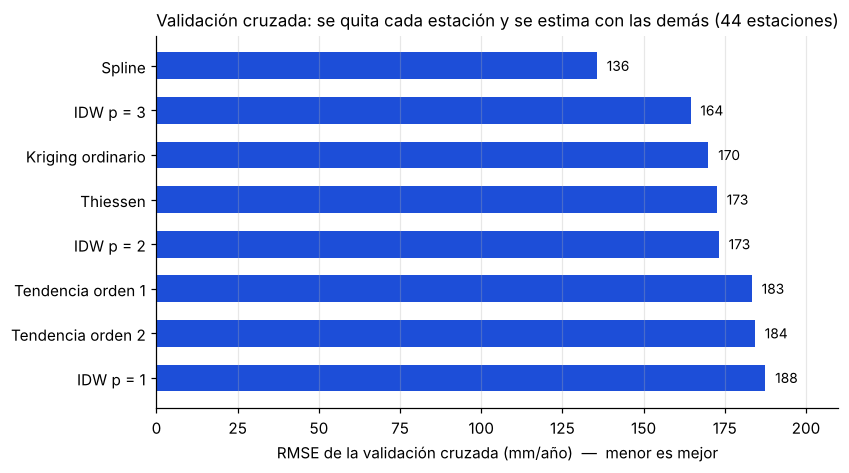

*Figura 12. Validación cruzada con la precipitación media anual (44 estaciones).*

El spline obtiene el menor error en las estaciones, pero genera valores irreales donde no hay datos (Figura 5). **El error en las estaciones no es el único criterio**: también debe verificarse la coherencia física de la superficie.

**Recomendaciones**

1. Revisar los datos: ubicación de las estaciones, vacíos temporales, valores extremos y estaciones de otras zonas climáticas.
2. Precipitación mensual: IDW como opción robusta; kriging o spline para promedios anuales.
3. Temperatura: incorporar siempre la altitud (gradiente con IDW o regresión con residuos).
4. Seleccionar $p$, $n$ y $\Gamma$ mediante validación cruzada y revisar los mapas fuera del rango de las estaciones.
5. Documentar el método y los parámetros para garantizar la reproducibilidad.

# Parte VI. El formato NetCDF

NetCDF es un formato **autodescriptivo y multidimensional**: almacena los datos junto con sus coordenadas, unidades y metadatos, y puede leerse desde Python, R, QGIS, Panoply o WEAP. Las convenciones **CF** (*Climate and Forecast*) estandarizan esa descripción (`degrees_north`, `days since …`, `standard_name`, `cell_methods`, `_FillValue`).

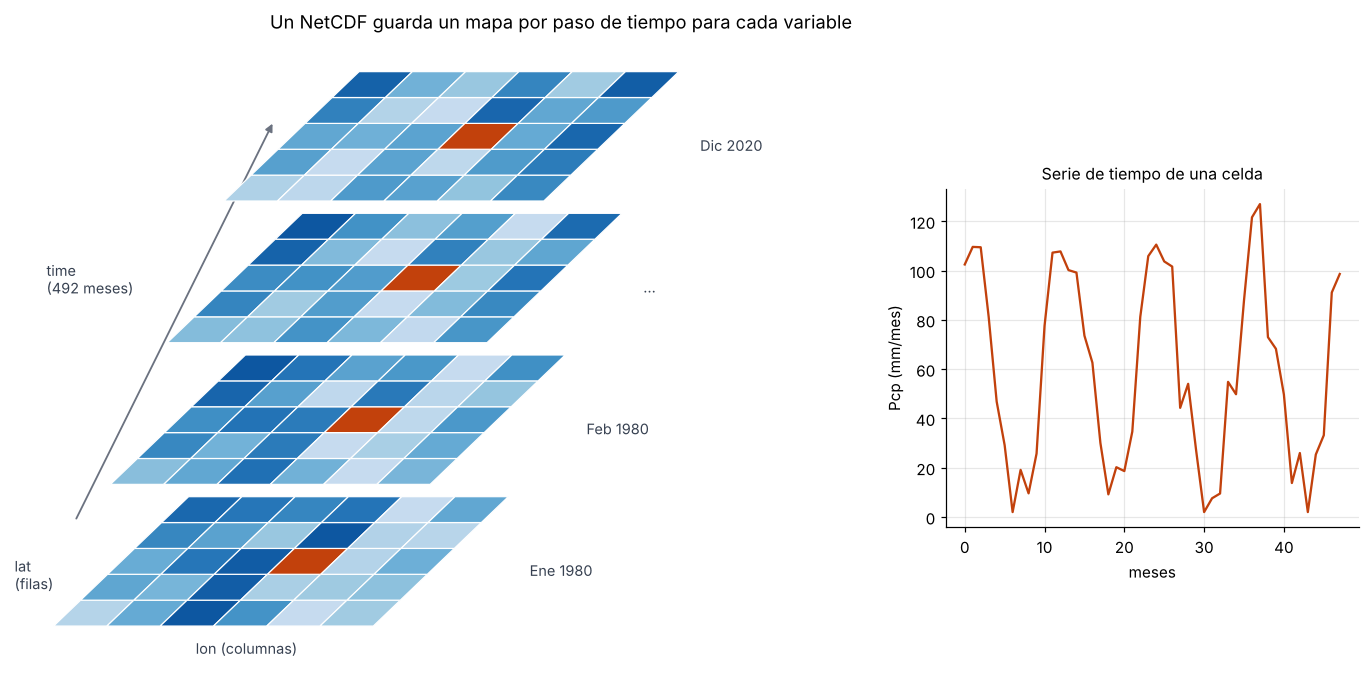

*Figura 13. Un mapa por paso de tiempo para cada variable; al fijar una celda se obtiene su serie de tiempo, que es lo que WEAP extrae para cada cuenca.*

**Archivo que se generará** (extensión completa del DEM):

| Variable | Dimensiones | Unidades | Descripción |
|---|---|---|---|
| `time` | `time` (492) | días desde 1980-01-01 | Primer día de cada mes |
| `lat`, `lon` | `lat` (376), `lon` (377) | grados | Centros de celda |
| `Pcp` | `time, lat, lon` | mm | Precipitación total mensual (`cell_methods: time: sum`) |
| `Ts` | `time, lat, lon` | °C | Temperatura media mensual (`cell_methods: time: mean`) |

# Parte VII. Ejercicio práctico: generación del NetCDF

Seleccione *Entorno de ejecución → Ejecutar todas* (2 a 5 minutos). Los pasos son: (1) parámetros, (2) carga de datos, (3) lectura y control de calidad, (4) agregación mensual, (5) malla del DEM, (6) funciones, (7) interpolación y NetCDF, (8) exploración del NetCDF, (9) series y mapas, (10) validación cruzada y (11) descarga.

## Paso 1. Parámetros

`POTENCIA` y `VECINOS` corresponden al IDW (Sección 3.2); `METODO_TEMP` y `GRADIENTE_TEMP`, al método de temperatura (Parte IV). $\Gamma$ es un valor definido por el usuario, no se calcula a partir de los datos.

In [ ]:
# =========================================================
# PARÁMETROS — lo único que normalmente se modifica
# =========================================================
USAR_DRIVE       = False    # 👈 False: los archivos se descargan de URL_CARPETA_DRIVE o se piden uno por uno; al final se descarga un .zip
                            #    True: se leen y se guardan en la carpeta de Drive montada (CARPETA_PROYECTO)
URL_CARPETA_DRIVE = "https://drive.google.com/drive/folders/1wqZY19lOPeGQYNgPjpLC1csRPfQzkJI8?usp=sharing"      # 👈 enlace a una carpeta de Drive compartida como "Cualquier persona con el enlace" con los archivos
                            #    ("" = se piden con el botón "Elegir archivos"). Solo se usa con USAR_DRIVE = False
CARPETA_PROYECTO = "/content/drive/MyDrive/InterpolacionClimaTiticaca"   # 👈 solo si USAR_DRIVE = True

ARCHIVO_PRECIP = "Datos_Precipitacion.csv"   # 👈 con URL_CARPETA_DRIVE deben llamarse así en la carpeta; si se cargan manualmente, se renombran
ARCHIVO_TEMP   = "Datos_Temperatura.csv"     # 👈
ARCHIVO_DEM    = "DEM_LagoTiticaca.tif"      # 👈
ARCHIVO_SHAPE  = "CuencaTiticaca.zip"       # 👈 .zip con el/los shapefile(s) para recortar los gráficos ("" = sin recorte).
                                             #    En la carpeta de Drive también sirven los .shp/.shx/.dbf/.prj sueltos
SHAPE_RECORTE  = ""                          # 👈 nombre del .shp (dentro del zip) que define el recorte; "" = el primero de polígonos

# ---------- Precipitación: IDW ----------
POTENCIA = 2      # 👈 A mayor valor, más peso a estaciones cercanas (casi siempre 2 o 1.5)
VECINOS  = 10     # 👈 Número de estaciones a tener en cuenta (5 a 10). También se usan en la temperatura con gradiente fijo

# ---------- Temperatura: relación con la altitud ----------
METODO_TEMP    = "gradiente_fijo"   # 👈 "gradiente_fijo": lleva las estaciones al nivel del mar con el gradiente, IDW y aplica el DEM
                                    #    "regresion": T = a + b·Elev ajustada cada mes con todas las estaciones (equivalente al script original en R)
GRADIENTE_TEMP = -6.5               # 👈 °C por km de altitud (solo para "gradiente_fijo"); valor de referencia, no se calcula
ESCALA_TEMP    = (-10, 20)          # 👈 límites (°C) de la escala de colores de los mapas de temperatura: azul < 0 °C (blanco) < rojo

# ---------- NetCDF ----------
NOMBRE_NC = "Clima_Titicaca"        # 👈 se completa con el periodo: Clima_Titicaca_1980-2020.nc
VAR_PR    = "Pcp"                   # nombre de la variable de precipitación en el NetCDF
VAR_TS    = "Ts"                    # nombre de la variable de temperatura en el NetCDF

# ---------- Opciones avanzadas (normalmente no se tocan) ----------
EXCLUIR_ESTACIONES    = []                    # códigos que no se usan, p. ej. ["X100030", "X100114"]
DISTANCIA             = "geodesica"           # "geodesica" (km) | "euclidiana" (grados, como gstat en R)
FORMATO_FECHA         = "%m/%d/%Y"            # formato de fechas de los CSV (12/31/2020)
VALORES_FALTANTES     = [-999, -9999, -99.9]  # códigos de dato faltante
MAX_DIAS_FALTANTES_PR = 3                     # más días faltantes -> el total mensual queda como faltante
MAX_DIAS_FALTANTES_TS = 10                    # más días faltantes -> el promedio mensual queda como faltante
MIN_ESTACIONES_REG    = 3                     # mínimo de estaciones para la regresión mensual
ENMASCARAR_CON_DEM    = True                  # celdas sin dato en el DEM quedan como NoData
FILL_VALUE            = -99999.0              # NoData en el NetCDF (el mismo del script de R)
DECIMALES_NC_PR       = 1                     # redondeo en el NetCDF: 0.1 mm (el .zip pesa ~4 veces menos)
DECIMALES_NC_TS       = 2                     # redondeo en el NetCDF: 0.01 °C
GUARDAR_ASCII         = False                 # True: además escribe un ASCII por mes y variable (≈ 800 MB)
INCLUIR_ELEVACION_NC  = False                 # True: agrega la elevación del DEM al NetCDF (útil en QGIS o Panoply;
                                              #       WEAP solo utiliza variables con dimensiones time, lat, lon)
DECIMALES_ASCII       = 2
CARPETA_SALIDA        = "Resultados_Clima_Titicaca"
EJECUTAR_VALIDACION   = True                  # validación cruzada (paso 10)

## Paso 2. Entorno y carga de datos

Instala las librerías necesarias y descarga los archivos desde la carpeta de Drive del curso (`URL_CARPETA_DRIVE`). Con `URL_CARPETA_DRIVE = ""`, se solicita cargar cada archivo manualmente.

In [ ]:
import os, sys, json, time, glob, shutil, zipfile, subprocess

try:
    import google.colab  # noqa: F401
    EN_COLAB = True
except ImportError:
    EN_COLAB = False

if EN_COLAB and USAR_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
elif EN_COLAB:
    CARPETA_PROYECTO = os.path.join("/content", os.path.basename(CARPETA_PROYECTO.rstrip("/")))
    os.makedirs(CARPETA_PROYECTO, exist_ok=True)

if not os.path.isdir(CARPETA_PROYECTO):
    raise FileNotFoundError(f"No existe la carpeta: {CARPETA_PROYECTO}\n"
                            "Revise la ruta (clic derecho sobre la carpeta en el panel de archivos → Copiar ruta).")
os.chdir(CARPETA_PROYECTO)

ENTRADAS = [ARCHIVO_PRECIP, ARCHIVO_TEMP, ARCHIVO_DEM] + ([ARCHIVO_SHAPE] if ARCHIVO_SHAPE else [])

def pedir_archivo(destino, descripcion, extensiones):
    """Pide UN archivo con el botón 'Elegir archivos' y lo guarda como 'destino'.
    Si ya se subió en esta sesión, no lo pide de nuevo."""
    if os.path.exists(destino):
        print(f"OK  {descripcion}: ya está cargado como '{destino}' "
              "(para reemplazarlo, elimínelo del panel de archivos y vuelva a ejecutar la celda)")
        return
    from google.colab import files
    print(f"\n>>  Cargue el {descripcion} ({' o '.join(extensiones)}):")
    subido = files.upload()
    if not subido:
        raise RuntimeError(f"No se cargó el {descripcion}. Vuelva a ejecutar la celda.")
    nombre, contenido = next(iter(subido.items()))
    if len(subido) > 1:
        print(f"⚠ Se cargaron {len(subido)} archivos; solo se utiliza '{nombre}'.")
    if not nombre.lower().endswith(tuple(extensiones)):
        for copia in subido:
            if copia not in ENTRADAS and os.path.exists(copia):
                os.remove(copia)
        raise ValueError(f"Para el {descripcion} se esperaba un archivo {' o '.join(extensiones)} y se cargó '{nombre}'.")
    with open(destino, "wb") as f:
        f.write(contenido)
    for copia in set(subido) - {destino}:
        if os.path.exists(copia) and copia not in ENTRADAS:
            os.remove(copia)
    print(f"OK  {descripcion}: '{nombre}' guardado como '{destino}' ({len(contenido) / 1e6:.1f} MB)")

def asegurar(modulo, paquete=None):
    try:
        return __import__(modulo)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", paquete or modulo], check=True)
        return __import__(modulo)

EXT_SHAPE = (".shp", ".shx", ".dbf", ".prj", ".cpg", ".sbn", ".sbx", ".qix")

def descargar_carpeta_publica(url):
    """Descarga con gdown una carpeta de Drive pública y copia los archivos de entrada a la carpeta de trabajo."""
    faltan = [a for a in ENTRADAS if not os.path.exists(a)]
    if not faltan:
        print("OK  Los archivos ya se descargaron en esta sesión "
              "(para descargarlos nuevamente, elimínelos del panel de archivos y vuelva a ejecutar la celda)")
        return
    gdown = asegurar("gdown")
    carpeta = os.path.join(CARPETA_PROYECTO, "descarga_drive")
    shutil.rmtree(carpeta, ignore_errors=True)
    print(">>  Descargando la carpeta de Drive...")
    error = "la descarga no devolvió archivos"
    try:
        rutas = gdown.download_folder(url=url, output=carpeta, quiet=True, use_cookies=False)
    except Exception as e:
        rutas, error = None, e
    if not rutas:
        raise RuntimeError("No se pudo descargar la carpeta de Drive. Verifique que el enlace corresponda a una CARPETA "
                           "compartida como 'Cualquier persona con el enlace' (las cuentas institucionales a veces "
                           f"no lo permiten) y que tenga menos de 50 archivos. Detalle: {error}")
    encontrados = {os.path.basename(r): r for r in rutas if os.path.isfile(r)}
    print(f"    {len(encontrados)} archivos en la carpeta: {sorted(encontrados)}")
    # El shape puede venir como .zip o como archivos sueltos (.shp, .shx, .dbf, .prj): en ese caso se arma el .zip
    if ARCHIVO_SHAPE in faltan and ARCHIVO_SHAPE not in encontrados:
        partes = [r for n, r in encontrados.items() if n.lower().endswith(EXT_SHAPE)]
        if any(p.lower().endswith(".shp") for p in partes):
            with zipfile.ZipFile(ARCHIVO_SHAPE, "w") as z:
                for r in partes:
                    z.write(r, os.path.basename(r))
            print(f"OK  {ARCHIVO_SHAPE}: armado con {len(partes)} archivos del shape")
    for a in faltan:
        if os.path.exists(a):
            continue
        if a not in encontrados:
            raise FileNotFoundError(f"La carpeta de Drive no contiene '{a}'. Corrija el nombre en el paso 1 "
                                    f"o en Drive. Archivos encontrados: {sorted(encontrados)}")
        shutil.copy(encontrados[a], a)
        print(f"OK  {a} ({os.path.getsize(a) / 1e6:.1f} MB)")

if EN_COLAB and not USAR_DRIVE:
    if URL_CARPETA_DRIVE:
        descargar_carpeta_publica(URL_CARPETA_DRIVE)
    else:
        pedir_archivo(ARCHIVO_PRECIP, "CSV de precipitación diaria", [".csv"])
        pedir_archivo(ARCHIVO_TEMP, "CSV de temperatura diaria", [".csv"])
        pedir_archivo(ARCHIVO_DEM, "DEM", [".tif", ".tiff"])
        if ARCHIVO_SHAPE:
            pedir_archivo(ARCHIVO_SHAPE, "shape de la cuenca comprimido", [".zip"])

faltan = [a for a in ENTRADAS if not os.path.exists(a)]
if faltan:
    raise FileNotFoundError(f"No se encontraron {faltan} en {CARPETA_PROYECTO}. Archivos presentes: {sorted(os.listdir('.'))}")

rasterio = asegurar("rasterio")
import rasterio.features
if ARCHIVO_SHAPE:
    gpd = asegurar("geopandas")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.io import netcdf_file

SALIDA = os.path.join(CARPETA_PROYECTO, CARPETA_SALIDA)
GRAFICOS = os.path.join(SALIDA, "graficos")
os.makedirs(GRAFICOS, exist_ok=True)
print("\nCarpeta de trabajo:", os.getcwd())
print("Resultados en:     ", SALIDA)

>>  Descargando la carpeta de Drive...
    9 archivos en la carpeta: ['CuencaTiticaca.zip', 'DEM_LagoTiticaca.tfw', 'DEM_LagoTiticaca.tif', 'DEM_LagoTiticaca.tif.aux.xml', 'DEM_LagoTiticaca.tif.vat.cpg', 'DEM_LagoTiticaca.tif.vat.dbf', 'DEM_LagoTiticaca.tif.xml', 'Datos_Precipitacion.csv', 'Datos_Temperatura.csv']
OK  Datos_Precipitacion.csv (3.4 MB)
OK  Datos_Temperatura.csv (3.4 MB)
OK  DEM_LagoTiticaca.tif (0.3 MB)
OK  CuencaTiticaca.zip (0.0 MB)

Carpeta de trabajo: /content/InterpolacionClimaTiticaca
Resultados en:      /content/InterpolacionClimaTiticaca/Resultados_Clima_Titicaca


## Paso 3. Lectura y control de calidad

Lectura de metadatos y series diarias; identificación de valores no numéricos, códigos de dato faltante, precipitación negativa y fechas duplicadas o ausentes.

In [ ]:
def leer_estaciones(archivo, variable, negativos_validos):
    """Lee un CSV con filas de metadatos (Codigo, Lat, Lon, Elev, Nombre) y una fila por día."""
    raw = pd.read_csv(archivo, header=None, dtype=str, keep_default_na=False)
    raw = raw.apply(lambda c: c.str.strip())
    fechas = pd.to_datetime(raw.iloc[:, 0], format=FORMATO_FECHA, errors="coerce")
    es_fecha = fechas.notna().to_numpy()

    meta = raw.loc[~es_fecha].set_index(0).T
    faltan = {"Codigo", "Lat", "Lon", "Elev"} - set(meta.columns)
    if faltan:
        raise ValueError(f"{archivo}: faltan filas de metadatos {faltan}. Encontradas: {list(meta.columns)}")
    est = pd.DataFrame({
        "Codigo": meta["Codigo"].to_numpy(),
        "Nombre": meta["Nombre"].to_numpy() if "Nombre" in meta else meta["Codigo"].to_numpy(),
        "Lat":  pd.to_numeric(meta["Lat"]).to_numpy(),
        "Lon":  pd.to_numeric(meta["Lon"]).to_numpy(),
        "Elev": pd.to_numeric(meta["Elev"]).to_numpy(),
    })
    if est["Codigo"].duplicated().any():
        raise ValueError(f"{archivo}: códigos repetidos {est.loc[est['Codigo'].duplicated(), 'Codigo'].tolist()}")

    texto = raw.loc[es_fecha].iloc[:, 1:]
    texto.columns = est["Codigo"].to_numpy()
    d = texto.apply(pd.to_numeric, errors="coerce")
    d.index = pd.DatetimeIndex(fechas[es_fecha].to_numpy(), name="Fecha")
    no_num = int((d.isna() & texto.ne("").to_numpy()).sum().sum())
    d = d.mask(d.isin(VALORES_FALTANTES))
    neg = 0
    if not negativos_validos:
        neg = int((d < 0).sum().sum())
        d = d.mask(d < 0)
    if d.index.duplicated().any():
        raise ValueError(f"{archivo}: fechas repetidas {d.index[d.index.duplicated()][:5].tolist()}")
    d = d.sort_index()
    completo = pd.date_range(d.index.min(), d.index.max(), freq="D")
    ausentes = len(completo) - len(d)
    d = d.reindex(completo)

    if EXCLUIR_ESTACIONES:
        mantener = ~est["Codigo"].isin(EXCLUIR_ESTACIONES).to_numpy()
        if (~mantener).any():
            print(f"{variable}: estaciones excluidas {est.loc[~mantener, 'Codigo'].tolist()}")
        est = est[mantener].reset_index(drop=True)
        d = d[est["Codigo"]]

    print(f"{variable}: {d.shape[1]} estaciones | {d.index.min():%Y-%m-%d} a {d.index.max():%Y-%m-%d} | "
          f"faltantes {d.isna().mean().mean():.2%} | días ausentes {ausentes} | no numéricos {no_num}"
          + ("" if negativos_validos else f" | negativos {neg}"))
    print(f"    elevación de estaciones: {est['Elev'].min():.0f} a {est['Elev'].max():.0f} m")
    return est, d

est_pr, diario_pr = leer_estaciones(ARCHIVO_PRECIP, "Precipitación", negativos_validos=False)
est_ts, diario_ts = leer_estaciones(ARCHIVO_TEMP, "Temperatura", negativos_validos=True)

Precipitación: 85 estaciones | 1980-01-01 a 2020-12-31 | faltantes 0.00% | días ausentes 0 | no numéricos 0 | negativos 0
    elevación de estaciones: 644 a 4655 m
Temperatura: 18 estaciones | 1980-01-01 a 2020-12-31 | faltantes 0.00% | días ausentes 0 | no numéricos 0
    elevación de estaciones: 3715 a 4360 m


## Paso 4. Agregación mensual

Suma mensual para la precipitación y promedio mensual para la temperatura. Se descartan los meses con más de `MAX_DIAS_FALTANTES_PR` (3) o `MAX_DIAS_FALTANTES_TS` (10) días sin dato.

In [ ]:
def a_mensual(diario, agregacion, max_faltantes):
    periodo = diario.index.to_period("M")
    con_dato = diario.notna().groupby(periodo).sum()
    faltantes = np.asarray(con_dato.index.days_in_month)[:, None] - con_dato.to_numpy()
    if agregacion == "suma":
        m = diario.groupby(periodo).sum(min_count=1)
    else:
        m = diario.groupby(periodo).mean()
    m = m.mask(faltantes > max_faltantes)
    m.index.name = "Mes"
    return m, int((faltantes > max_faltantes).sum())

def guardar_tabla(est, mensual, ruta, decimales):
    salida = mensual.round(decimales)
    salida.index = salida.index.strftime("%Y-%m")
    encabezado = est.set_index("Codigo")[["Lat", "Lon", "Elev", "Nombre"]].T
    pd.concat([encabezado, salida.astype(object)]).to_csv(ruta, index_label="Codigo")

mensual_pr, inval_pr = a_mensual(diario_pr, "suma", MAX_DIAS_FALTANTES_PR)
mensual_ts, inval_ts = a_mensual(diario_ts, "promedio", MAX_DIAS_FALTANTES_TS)

meses = mensual_pr.index.intersection(mensual_ts.index)
if len(meses) < max(len(mensual_pr), len(mensual_ts)):
    print(f"⚠ Los periodos no coinciden; se usa el periodo común {meses[0]} a {meses[-1]}.")
mensual_pr, mensual_ts = mensual_pr.loc[meses], mensual_ts.loc[meses]

guardar_tabla(est_pr, mensual_pr, os.path.join(SALIDA, "PR_mensual_estaciones.csv"), 2)
guardar_tabla(est_ts, mensual_ts, os.path.join(SALIDA, "TS_mensual_estaciones.csv"), 2)

print(f"Meses: {len(meses)} ({meses[0]} a {meses[-1]})")
print(f"Estación-meses descartados por faltantes: precipitación {inval_pr}, temperatura {inval_ts}")
n_pr, n_ts = mensual_pr.notna().sum(axis=1), mensual_ts.notna().sum(axis=1)
print(f"Estaciones con dato por mes: precipitación {n_pr.min()}-{n_pr.max()}, temperatura {n_ts.min()}-{n_ts.max()}")
print("Guardado: PR_mensual_estaciones.csv, TS_mensual_estaciones.csv")

Meses: 492 (1980-01 a 2020-12)
Estación-meses descartados por faltantes: precipitación 0, temperatura 0
Estaciones con dato por mes: precipitación 85-85, temperatura 18-18
Guardado: PR_mensual_estaciones.csv, TS_mensual_estaciones.csv


## Paso 5. Malla del DEM y área de estudio

La malla del NetCDF (filas, columnas, tamaño de celda y esquina) se toma del DEM; los valores se calculan en el centro de cada celda. El shapefile solo recorta los gráficos y define el promedio de la cuenca.

DEM: 376 filas x 377 columnas | celda 0.008333334° x 0.008333334° | x -71.16666 a -68.02499 | y -17.16667 a -14.03334 | elevación 404 a 6130 m
Capas: ['CuencaTiticaca.shp'] | recorte con 'CuencaTiticaca.shp': 69,083 celdas (elevación 3804 a 6130 m)


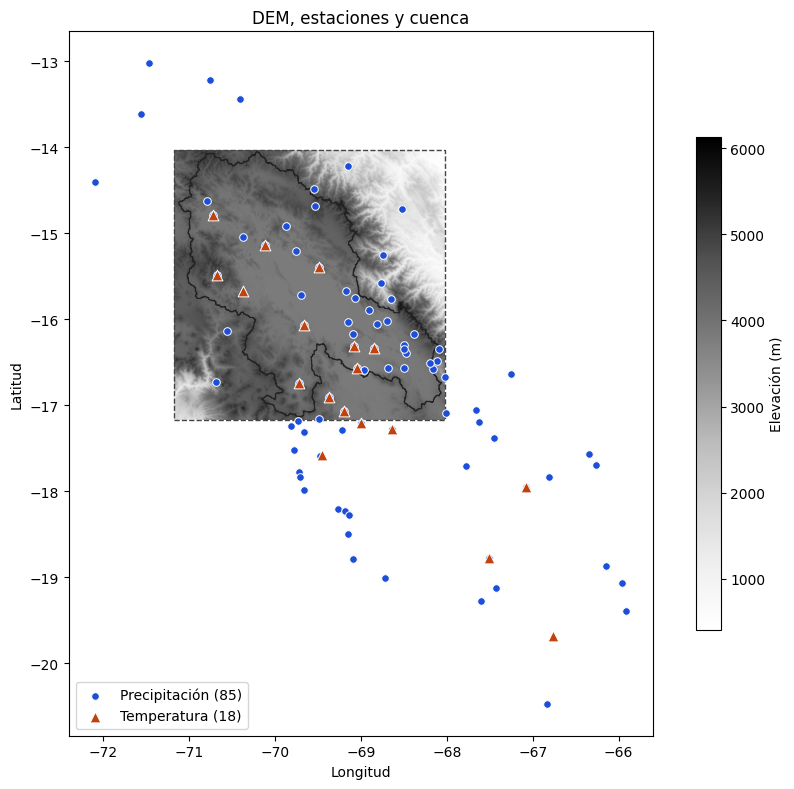

In [ ]:
with rasterio.open(ARCHIVO_DEM) as src:
    dem = src.read(1).astype("float64")
    nodata_dem, T, crs = src.nodata, src.transform, src.crs
    nrows, ncols = src.height, src.width
if nodata_dem is not None and not np.isnan(nodata_dem):
    dem[dem == nodata_dem] = np.nan
if (crs.to_epsg() if crs is not None else None) != 4326:
    raise ValueError(f"El DEM debe estar en WGS84 (EPSG:4326) y está en: {crs}. Reproyéctelo antes de continuar.")
if T.b != 0 or T.d != 0:
    raise ValueError("El DEM tiene rotación; no está soportado.")

dx, dy = T.a, -T.e
xmin, ymax = T.c, T.f
xmax, ymin = xmin + ncols * dx, ymax - nrows * dy
lon_c = xmin + (np.arange(ncols) + 0.5) * dx            # centros de celda (como xllcorner + cellsize/2 en el R)
lat_c = ymax - (np.arange(nrows) + 0.5) * dy            # de norte a sur
LON, LAT = np.meshgrid(lon_c, lat_c)
valida = ~np.isnan(dem) if ENMASCARAR_CON_DEM else np.ones(dem.shape, dtype=bool)
print(f"DEM: {nrows} filas x {ncols} columnas | celda {dx:.9f}° x {dy:.9f}° | "
      f"x {xmin:.5f} a {xmax:.5f} | y {ymin:.5f} a {ymax:.5f} | elevación {np.nanmin(dem):.0f} a {np.nanmax(dem):.0f} m")

# ---------- Shapes (solo para gráficos y series de la cuenca) ----------
capas = {}
en_cuenca = valida.copy()
if ARCHIVO_SHAPE:
    carpeta_shape = os.path.join(CARPETA_PROYECTO, "shapes")
    shutil.rmtree(carpeta_shape, ignore_errors=True)
    with zipfile.ZipFile(ARCHIVO_SHAPE) as z:
        z.extractall(carpeta_shape)
    for shp in sorted(glob.glob(os.path.join(carpeta_shape, "**", "*.shp"), recursive=True)):
        g = gpd.read_file(shp)
        if g.crs is None:
            print(f"⚠ {os.path.basename(shp)} no tiene .prj; se asume WGS84.")
        elif g.crs.to_epsg() != 4326:
            g = g.to_crs(epsg=4326)
        capas[os.path.basename(shp)] = [geom for geom in g.geometry if geom is not None]
    if not capas:
        raise ValueError(f"No se encontró ningún .shp dentro de {ARCHIVO_SHAPE}.")
    poligonales = [n for n, gs in capas.items()
                   if gs and gs[0].__geo_interface__["type"] in ("Polygon", "MultiPolygon")]
    nombre_recorte = SHAPE_RECORTE or (poligonales[0] if poligonales else None)
    if nombre_recorte not in capas or nombre_recorte not in poligonales:
        raise ValueError(f"SHAPE_RECORTE='{SHAPE_RECORTE}' no es una capa de polígonos. Disponibles: {poligonales}")
    en_cuenca = rasterio.features.geometry_mask(capas[nombre_recorte], out_shape=dem.shape,
                                                transform=T, invert=True) & valida
    if not en_cuenca.any():
        print("⚠ El shape no cae sobre el DEM; los gráficos usan la extensión completa.")
        en_cuenca = valida.copy()
    print(f"Capas: {list(capas)} | recorte con '{nombre_recorte}': {en_cuenca.sum():,} celdas "
          f"(elevación {np.nanmin(dem[en_cuenca]):.0f} a {np.nanmax(dem[en_cuenca]):.0f} m)")

filas, cols = np.where(en_cuenca)
r0, r1, c0, c1 = filas.min(), filas.max() + 1, cols.min(), cols.max() + 1
ext_recorte = (xmin + c0 * dx, xmin + c1 * dx, ymax - r1 * dy, ymax - r0 * dy)

def recortar(grilla):
    """Celdas fuera de la cuenca -> NaN, y recorte al rectángulo de la cuenca (solo para gráficos)."""
    return np.where(en_cuenca, grilla, np.nan)[r0:r1, c0:c1]

def dibujar_capas(ax, color="#222", lw=0.8):
    for gs in capas.values():
        for g in gs:
            gi = g.__geo_interface__
            tipo, coords = gi["type"], gi["coordinates"]
            if tipo == "Polygon":
                anillos = coords
            elif tipo == "MultiPolygon":
                anillos = [a for p in coords for a in p]
            elif tipo == "LineString":
                anillos = [coords]
            elif tipo == "MultiLineString":
                anillos = coords
            else:
                continue
            for a in anillos:
                a = np.asarray(a)
                ax.plot(a[:, 0], a[:, 1], color=color, lw=lw)

dentro_pr = (est_pr["Lon"].between(xmin, xmax) & est_pr["Lat"].between(ymin, ymax)).to_numpy()
dentro_ts = (est_ts["Lon"].between(xmin, xmax) & est_ts["Lat"].between(ymin, ymax)).to_numpy()

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(dem, extent=(xmin, xmax, ymin, ymax), cmap="Greys", origin="upper")
ax.scatter(est_pr["Lon"], est_pr["Lat"], s=30, c="#1d4ed8", edgecolors="white", linewidths=0.7,
           label=f"Precipitación ({len(est_pr)})", zorder=3)
ax.scatter(est_ts["Lon"], est_ts["Lat"], s=60, marker="^", c="#c2410c", edgecolors="white", linewidths=0.7,
           label=f"Temperatura ({len(est_ts)})", zorder=4)
dibujar_capas(ax)
ax.add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, fill=False, ec="#444", lw=1, ls="--"))
ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud"); ax.set_title("DEM, estaciones y cuenca")
ax.legend(loc="lower left")
plt.colorbar(im, ax=ax, shrink=0.7, label="Elevación (m)")
plt.tight_layout(); plt.savefig(os.path.join(GRAFICOS, "01_DEM_estaciones.png"), dpi=200); plt.show()

## Paso 6. Funciones

IDW (Sección 3.2), regresión temperatura–altitud (Parte IV) y escritura del NetCDF con atributos CF (Parte VI).

In [ ]:
R_TIERRA_KM = 6371.0

def _cartesianas(lon, lat):
    lon, lat = np.radians(lon), np.radians(lat)
    return np.column_stack([np.cos(lat) * np.cos(lon), np.cos(lat) * np.sin(lon), np.sin(lat)])

def preparar_idw(lon_est, lat_est, lon_obj, lat_obj, vecinos, potencia, distancia="geodesica"):
    k = min(vecinos, len(lon_est))
    if distancia == "geodesica":
        cuerda, idx = cKDTree(_cartesianas(lon_est, lat_est)).query(_cartesianas(lon_obj, lat_obj), k=k)
        d = 2 * R_TIERRA_KM * np.arcsin(np.clip(cuerda / 2, 0, 1))
    elif distancia == "euclidiana":
        d, idx = cKDTree(np.column_stack([lon_est, lat_est])).query(np.column_stack([lon_obj, lat_obj]), k=k)
    else:
        raise ValueError('DISTANCIA debe ser "geodesica" o "euclidiana"')
    if k == 1:
        d, idx = d[:, None], idx[:, None]
    exacto = d <= 1e-10
    with np.errstate(divide="ignore"):
        w = 1.0 / d ** potencia
    filas_ex = exacto.any(axis=1)
    w[filas_ex] = exacto[filas_ex]
    return idx, w / w.sum(axis=1, keepdims=True)

def idw_por_mes(V, lon_est, lat_est, lon_obj, lat_obj, vecinos, potencia, distancia):
    """V: meses x estaciones (NaN = sin dato). Entrega (i, valores, n_estaciones)."""
    cache = {}
    for i, v in enumerate(V):
        ok = ~np.isnan(v)
        if not ok.any():
            yield i, np.full(len(lon_obj), np.nan), 0
            continue
        clave = ok.tobytes()
        if clave not in cache:
            if len(cache) >= 8:
                cache.clear()
            cache[clave] = preparar_idw(lon_est[ok], lat_est[ok], lon_obj, lat_obj, vecinos, potencia, distancia)
        idx, w = cache[clave]
        yield i, (w * v[ok][idx]).sum(axis=1), int(ok.sum())

def regresion_altitud(z, t):
    """T = a + b·z por mínimos cuadrados. Devuelve a (°C), b (°C/m), R²."""
    b, a = np.polyfit(z, t, 1)
    ss = ((t - t.mean()) ** 2).sum()
    r2 = 1 - ((t - (a + b * z)) ** 2).sum() / ss if ss > 0 else np.nan
    return a, b, r2

def escribir_ascii(ruta, matriz, decimales=2, nodata=-9999):
    enc = [f"ncols         {ncols}", f"nrows         {nrows}",
           f"xllcorner     {xmin:.10f}", f"yllcorner     {ymin:.10f}"]
    enc += [f"cellsize      {dx:.12f}"] if abs(dx - dy) < 1e-9 else [f"dx            {dx:.12f}", f"dy            {dy:.12f}"]
    enc.append(f"NODATA_value  {nodata}")
    np.savetxt(ruta, np.where(np.isnan(matriz), nodata, matriz), fmt=f"%.{decimales}f",
               header="\n".join(enc), comments="")

def escribir_netcdf(ruta, meses, variables, atributos):
    """NetCDF clásico (64-bit offset), dimensiones time x lat x lon. Lo leen R (ncdf4/raster/terra), QGIS, Python, Panoply."""
    t0 = pd.Timestamp(meses[0].year, 1, 1)
    dias = np.array([(m.to_timestamp() - t0).days for m in meses], dtype="f8")
    fill = np.float32(FILL_VALUE)
    with netcdf_file(ruta, "w", version=2) as nc:
        for k, v in atributos.items():
            setattr(nc, k, v)
        nc.createDimension("time", len(meses))
        nc.createDimension("lat", nrows)
        nc.createDimension("lon", ncols)
        vt = nc.createVariable("time", "f8", ("time",))
        vt[:] = dias
        vt.units, vt.calendar, vt.long_name, vt.standard_name, vt.axis = \
            f"days since {t0:%Y-%m-%d} 00:00:00", "standard", "time", "time", "T"
        vy = nc.createVariable("lat", "f8", ("lat",))
        vy[:] = lat_c
        vy.units, vy.long_name, vy.standard_name, vy.axis = "degrees_north", "Latitude", "latitude", "Y"
        vx = nc.createVariable("lon", "f8", ("lon",))
        vx[:] = lon_c
        vx.units, vx.long_name, vx.standard_name, vx.axis = "degrees_east", "Longitude", "longitude", "X"
        for nombre, (datos, dims, attrs, decimales) in variables.items():
            v = nc.createVariable(nombre, "f4", dims)
            if decimales is not None:
                datos = np.round(datos, decimales)
            v[:] = np.where(np.isnan(datos), fill, datos).astype("f4")
            v._FillValue = fill
            v.missing_value = fill
            for k, val in attrs.items():
                setattr(v, k, val)
    return dias

## Paso 7. Interpolación mensual y NetCDF

Precipitación por IDW; temperatura por gradiente fijo con IDW (o por regresión, según `METODO_TEMP`); escritura de ambas variables en un único NetCDF.

In [ ]:
nt = len(meses)
lon_obj, lat_obj, z_obj = LON[valida], LAT[valida], dem[valida]
t_inicio = time.time()

# ---------- Precipitación: IDW ----------
PR = np.full((nt, nrows, ncols), np.nan, dtype="float32")
V_pr = mensual_pr[est_pr["Codigo"]].to_numpy(float)
for i, pred, n in idw_por_mes(V_pr, est_pr["Lon"].to_numpy(float), est_pr["Lat"].to_numpy(float),
                              lon_obj, lat_obj, VECINOS, POTENCIA, DISTANCIA):
    PR[i][valida] = pred
print(f"Precipitación lista ({time.time() - t_inicio:.0f} s)")

# ---------- Temperatura: relación con la altitud ----------
TS = np.full((nt, nrows, ncols), np.nan, dtype="float32")
V_ts = mensual_ts[est_ts["Codigo"]].to_numpy(float)
z_ts = est_ts["Elev"].to_numpy(float)

diag = []                                   # regresión mensual T vs. altitud (diagnóstico, para ambos métodos)
for i, v in enumerate(V_ts):
    ok = ~np.isnan(v)
    a, b, r2 = regresion_altitud(z_ts[ok], v[ok]) if ok.sum() >= MIN_ESTACIONES_REG else (np.nan,) * 3
    diag.append({"Mes": str(meses[i]), "estaciones": int(ok.sum()), "intercepto_C": a,
                 "gradiente_C_por_km": b * 1000, "R2": r2})
diag = pd.DataFrame(diag)

if METODO_TEMP == "gradiente_fijo":
    G = GRADIENTE_TEMP / 1000.0                                  # °C/m
    T0 = V_ts - G * z_ts[None, :]                                # temperatura llevada al nivel del mar
    for i, pred, n in idw_por_mes(T0, est_ts["Lon"].to_numpy(float), est_ts["Lat"].to_numpy(float),
                                  lon_obj, lat_obj, VECINOS, POTENCIA, DISTANCIA):
        TS[i][valida] = pred + G * z_obj
elif METODO_TEMP == "regresion":
    campo = None
    for i, fila in diag.iterrows():
        if not np.isnan(fila["gradiente_C_por_km"]):
            campo = fila["intercepto_C"] + fila["gradiente_C_por_km"] / 1000 * z_obj
        else:
            print(f"⚠ {fila['Mes']}: menos de {MIN_ESTACIONES_REG} estaciones; se repite el campo anterior.")
        if campo is not None:
            TS[i][valida] = campo
else:
    raise ValueError('METODO_TEMP debe ser "gradiente_fijo" o "regresion"')
diag.round(4).to_csv(os.path.join(SALIDA, "TS_regresion_altitud_mensual.csv"), index=False)
print(f"Temperatura lista ({time.time() - t_inicio:.0f} s) | método: {METODO_TEMP}"
      + (f" ({GRADIENTE_TEMP} °C/km)" if METODO_TEMP == "gradiente_fijo" else ""))
print(f"Gradiente de la regresión mensual (diagnóstico): {diag['gradiente_C_por_km'].mean():.2f} °C/km en promedio "
      f"(rango {diag['gradiente_C_por_km'].min():.2f} a {diag['gradiente_C_por_km'].max():.2f}), R² medio {diag['R2'].mean():.2f}")

# ---------- NetCDF ----------
archivo_nc = os.path.join(SALIDA, f"{NOMBRE_NC}_{meses[0].year}-{meses[-1].year}.nc")
atributos = {
    "Conventions": "CF-1.8",
    "title": "Precipitacion y temperatura mensual interpoladas - Cuenca del Lago Titicaca",
    "source": f"Estaciones: {ARCHIVO_PRECIP} ({len(est_pr)}), {ARCHIVO_TEMP} ({len(est_ts)}); DEM: {ARCHIVO_DEM}",
    "method_precipitation": f"IDW mensual, potencia={POTENCIA}, vecinos={VECINOS}, distancia={DISTANCIA}",
    "method_temperature": (f"gradiente fijo {GRADIENTE_TEMP} C/km + IDW (potencia={POTENCIA}, vecinos={VECINOS}) + DEM"
                           if METODO_TEMP == "gradiente_fijo" else "regresion lineal mensual T = a + b*Elev aplicada al DEM"),
    "references": "Estaciones SENAMHI Peru y SENAMHI Bolivia; MMAyA y SEI (2024), Balance Hidrico de Bolivia 1980-2020, doi:10.5281/zenodo.10850934",
    "history": f"Creado {time.strftime('%Y-%m-%d %H:%M')} con el cuaderno del curso Modelado en WEAP "
               "(Datos Climaticos y Metodos de Interpolacion)",
}
variables_nc = {
    VAR_PR: (PR, ("time", "lat", "lon"), {"units": "mm", "long_name": "Precipitacion total mensual (mm/mes)",
                                          "standard_name": "lwe_thickness_of_precipitation_amount",
                                          "cell_methods": "time: sum"}, DECIMALES_NC_PR),
    VAR_TS: (TS, ("time", "lat", "lon"), {"units": "degC", "long_name": "Temperatura media mensual",
                                          "standard_name": "air_temperature", "cell_methods": "time: mean"}, DECIMALES_NC_TS),
}
if INCLUIR_ELEVACION_NC:
    variables_nc["Elev"] = (dem.astype("float32"), ("lat", "lon"), {"units": "m", "long_name": "Elevacion del DEM"}, None)
dias_nc = escribir_netcdf(archivo_nc, meses, variables_nc, atributos)
print(f"\nNetCDF: {os.path.basename(archivo_nc)} ({os.path.getsize(archivo_nc) / 1e6:.0f} MB) | "
      f"{VAR_PR} y {VAR_TS}: {nt} meses x {nrows} filas x {ncols} columnas")

if GUARDAR_ASCII:
    for nombre, datos in (("PR", PR), ("TS", TS)):
        carpeta = os.path.join(SALIDA, f"{nombre}_ASCII"); os.makedirs(carpeta, exist_ok=True)
        for i, m in enumerate(meses):
            escribir_ascii(os.path.join(carpeta, f"{nombre}_{m.year}_{m.month:02d}.asc"), datos[i], DECIMALES_ASCII)
    print("ASCII guardados en PR_ASCII/ y TS_ASCII/")

with open(os.path.join(SALIDA, "parametros.json"), "w", encoding="utf-8") as f:
    json.dump({"potencia": POTENCIA, "vecinos": VECINOS, "distancia": DISTANCIA, "metodo_temp": METODO_TEMP,
               "gradiente_temp_C_km": GRADIENTE_TEMP, "max_dias_faltantes_pr": MAX_DIAS_FALTANTES_PR,
               "max_dias_faltantes_ts": MAX_DIAS_FALTANTES_TS, "excluir_estaciones": EXCLUIR_ESTACIONES,
               "periodo": [str(meses[0]), str(meses[-1])], "netcdf": os.path.basename(archivo_nc),
               "malla": {"nrows": nrows, "ncols": ncols, "xllcorner": xmin, "yllcorner": ymin, "dx": dx, "dy": dy},
               "shape_recorte": nombre_recorte if ARCHIVO_SHAPE else None,
               "ejecutado": time.strftime("%Y-%m-%d %H:%M")}, f, indent=2, ensure_ascii=False)

Precipitación lista (11 s)
Temperatura lista (17 s) | método: gradiente_fijo (-6.5 °C/km)
Gradiente de la regresión mensual (diagnóstico): -9.84 °C/km en promedio (rango -11.79 a -7.77), R² medio 0.79

NetCDF: Clima_Titicaca_1980-2020.nc (558 MB) | Pcp y Ts: 492 meses x 376 filas x 377 columnas


## Paso 8. Exploración del NetCDF

Estructura del archivo (equivalente a `ncdump -h`), mapas de un mes leídos desde el archivo y serie de tiempo de una celda, que es la operación que WEAP realiza para cada cuenca. Modifique `MES_EJEMPLO` y `PUNTO_EJEMPLO` para explorar otros meses y ubicaciones.

Archivo: Clima_Titicaca_1980-2020.nc  (558 MB)

Dimensiones:
    time = 492
    lat = 376
    lon = 377

Variables:
    float32 Pcp(time, lat, lon)
        Pcp:_FillValue = -99999.0
        Pcp:missing_value = -99999.0
        Pcp:units = mm
        Pcp:long_name = Precipitacion total mensual (mm/mes)
        Pcp:standard_name = lwe_thickness_of_precipitation_amount
        Pcp:cell_methods = time: sum
    float32 Ts(time, lat, lon)
        Ts:_FillValue = -99999.0
        Ts:missing_value = -99999.0
        Ts:units = degC
        Ts:long_name = Temperatura media mensual
        Ts:standard_name = air_temperature
        Ts:cell_methods = time: mean
    float64 time(time)
        time:units = days since 1980-01-01 00:00:00
        time:calendar = standard
        time:long_name = time
        time:standard_name = time
        time:axis = T
    float64 lon(lon)
        lon:units = degrees_east
        lon:long_name = Longitude
        lon:standard_name = longitude
        lon:axis = X


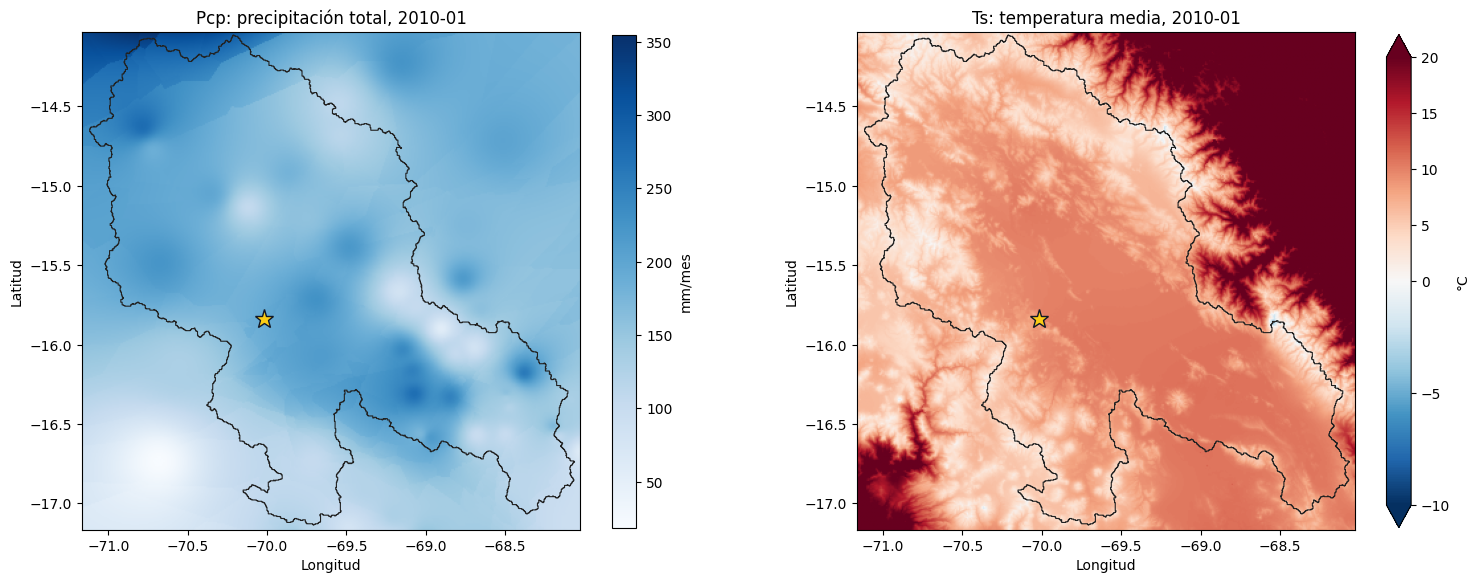



──────────────────────────────────────────────────────────────────────────────────────────
  Serie de tiempo extraída del NetCDF en el punto de ejemplo
──────────────────────────────────────────────────────────────────────────────────────────



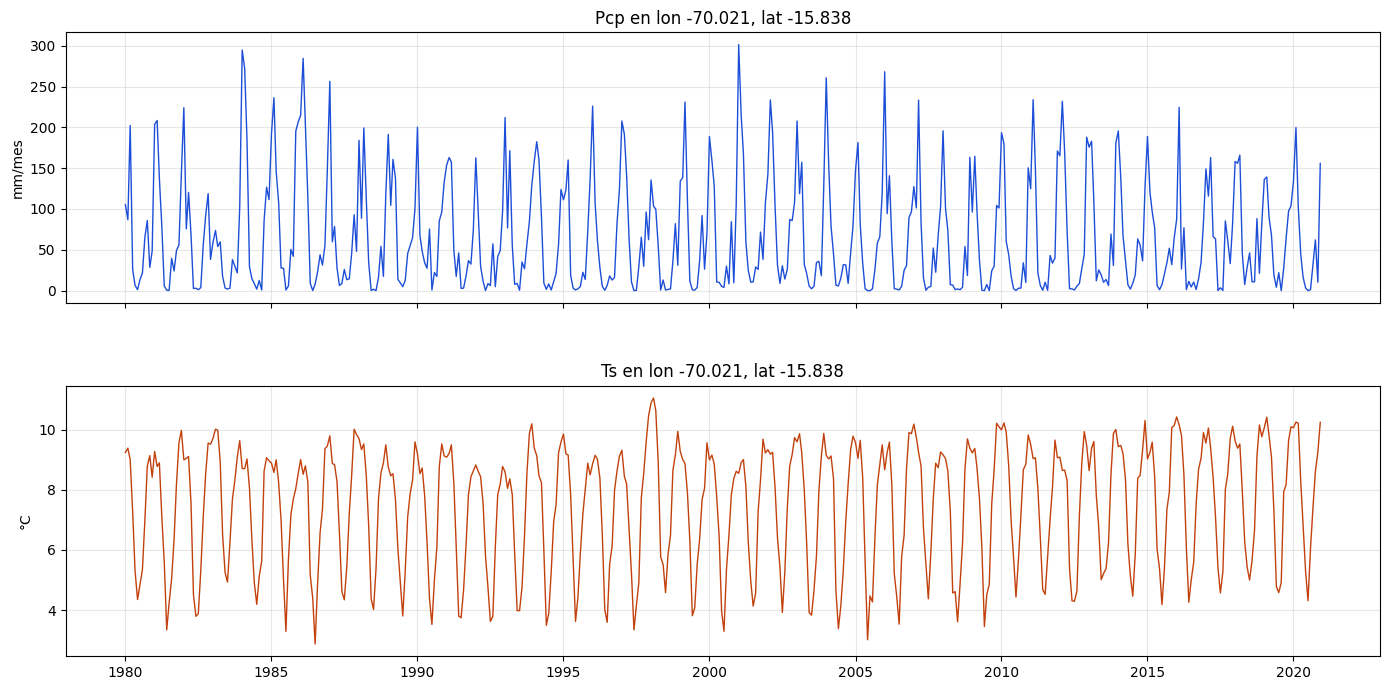

In [ ]:
# =========================================================
# EXPLORACIÓN DEL NETCDF GENERADO
# =========================================================
MES_EJEMPLO   = "2010-01"            # 👈 mes que se desea visualizar (AAAA-MM)
PUNTO_EJEMPLO = (-70.02, -15.84)     # 👈 (longitud, latitud) del punto donde se extrae la serie (por defecto, Puno)

from matplotlib.colors import TwoSlopeNorm

def _texto(v):
    return v.decode() if isinstance(v, bytes) else v

def describir_netcdf(ruta):
    """Muestra la estructura del archivo, de forma similar al comando 'ncdump -h'."""
    with netcdf_file(ruta, "r", mmap=False) as nc:
        print(f"Archivo: {os.path.basename(ruta)}  ({os.path.getsize(ruta) / 1e6:.0f} MB)\n")
        print("Dimensiones:")
        for d, n in nc.dimensions.items():
            print(f"    {d} = {n}")
        print("\nVariables:")
        for nombre, v in nc.variables.items():
            print(f"    {v.data.dtype.name} {nombre}({', '.join(v.dimensions)})")
            for a, val in v._attributes.items():
                print(f"        {nombre}:{a} = {_texto(val)}")
        print("\nAtributos globales:")
        for a, val in nc._attributes.items():
            print(f"    :{a} = {_texto(val)}")

describir_netcdf(archivo_nc)

# ---------- Lectura del archivo, tal como lo haría cualquier otro programa ----------
with netcdf_file(archivo_nc, "r", mmap=False) as nc:
    t_nc = nc.variables["time"][:].copy()
    ref = pd.Timestamp(_texto(nc.variables["time"].units).split("since")[1].strip())
    fechas_nc = ref + pd.to_timedelta(t_nc, unit="D")
    lat_nc, lon_nc = nc.variables["lat"][:].copy(), nc.variables["lon"][:].copy()
    etiquetas = list(fechas_nc.strftime("%Y-%m"))
    if MES_EJEMPLO not in etiquetas:
        raise ValueError(f"MES_EJEMPLO = '{MES_EJEMPLO}' no está en el archivo ({etiquetas[0]} a {etiquetas[-1]}).")
    i_mes = etiquetas.index(MES_EJEMPLO)
    lon_p, lat_p = PUNTO_EJEMPLO
    if not (lon_nc.min() <= lon_p <= lon_nc.max() and lat_nc.min() <= lat_p <= lat_nc.max()):
        raise ValueError(f"PUNTO_EJEMPLO {PUNTO_EJEMPLO} está fuera de la malla del NetCDF.")
    fila, col = int(np.abs(lat_nc - lat_p).argmin()), int(np.abs(lon_nc - lon_p).argmin())
    leer = lambda arr: np.where(arr == np.float32(FILL_VALUE), np.nan, arr.astype(float))
    pr_mes, ts_mes = leer(nc.variables[VAR_PR][i_mes]), leer(nc.variables[VAR_TS][i_mes])
    serie_pr_p, serie_ts_p = leer(nc.variables[VAR_PR][:, fila, col]), leer(nc.variables[VAR_TS][:, fila, col])

print(f"\nCelda más cercana a {PUNTO_EJEMPLO}: fila {fila}, columna {col} "
      f"(lon {lon_nc[col]:.4f}, lat {lat_nc[fila]:.4f}, elevación {dem[fila, col]:.0f} m)")

print("\n\n" + "─" * 90 + f"\n  Mapas leídos del NetCDF: {MES_EJEMPLO} (extensión completa del DEM)\n" + "─" * 90 + "\n")
ext_nc = (xmin, xmax, ymin, ymax)
fig, axs = plt.subplots(1, 2, figsize=(15, 6.5))
im = axs[0].imshow(pr_mes, extent=ext_nc, origin="upper", cmap="Blues")
plt.colorbar(im, ax=axs[0], shrink=0.8, label="mm/mes")
axs[0].set_title(f"{VAR_PR}: precipitación total, {MES_EJEMPLO}")
im = axs[1].imshow(ts_mes, extent=ext_nc, origin="upper", cmap="RdBu_r",
                   norm=TwoSlopeNorm(vmin=ESCALA_TEMP[0], vcenter=0, vmax=ESCALA_TEMP[1]))
plt.colorbar(im, ax=axs[1], shrink=0.8, label="°C", extend="both")
axs[1].set_title(f"{VAR_TS}: temperatura media, {MES_EJEMPLO}")
for ax in axs:
    dibujar_capas(ax)
    ax.plot(lon_p, lat_p, marker="*", ms=14, color="#facc15", mec="#111827", zorder=5)
    ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
    ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
plt.tight_layout(w_pad=6); plt.savefig(os.path.join(GRAFICOS, f"netcdf_mapas_{MES_EJEMPLO}.png"), dpi=200); plt.show()

print("\n\n" + "─" * 90 + "\n  Serie de tiempo extraída del NetCDF en el punto de ejemplo\n" + "─" * 90 + "\n")
fig, axs = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axs[0].plot(fechas_nc, serie_pr_p, color="#1d4ed8", lw=1)
axs[0].set_ylabel("mm/mes"); axs[0].set_title(f"{VAR_PR} en lon {lon_nc[col]:.3f}, lat {lat_nc[fila]:.3f}")
axs[1].plot(fechas_nc, serie_ts_p, color="#c2410c", lw=1)
axs[1].set_ylabel("°C"); axs[1].set_title(f"{VAR_TS} en lon {lon_nc[col]:.3f}, lat {lat_nc[fila]:.3f}")
for ax in axs:
    ax.grid(alpha=0.3)
plt.tight_layout(h_pad=4); plt.savefig(os.path.join(GRAFICOS, "netcdf_serie_punto.png"), dpi=200); plt.show()

## Paso 9. Series de la cuenca y mapas

Series mensuales promedio de la cuenca (ponderadas por área), mapas medios anuales, climatologías mensuales y relación temperatura–altitud.



──────────────────────────────────────────────────────────────────────────────────────────
  Series mensuales promedio de la cuenca
──────────────────────────────────────────────────────────────────────────────────────────

Guardado: Series_mensuales_cuenca.csv


,Fecha,Anio,Mes,Pcp_mm,Ts_degC
0,1980-01,1980,1,106.52,7.067
1,1980-02,1980,2,83.24,7.176
2,1980-03,1980,3,164.44,6.730
3,1980-04,1980,4,22.19,5.065
4,1980-05,1980,5,10.28,3.183




──────────────────────────────────────────────────────────────────────────────────────────
  Mapas medios anuales
──────────────────────────────────────────────────────────────────────────────────────────



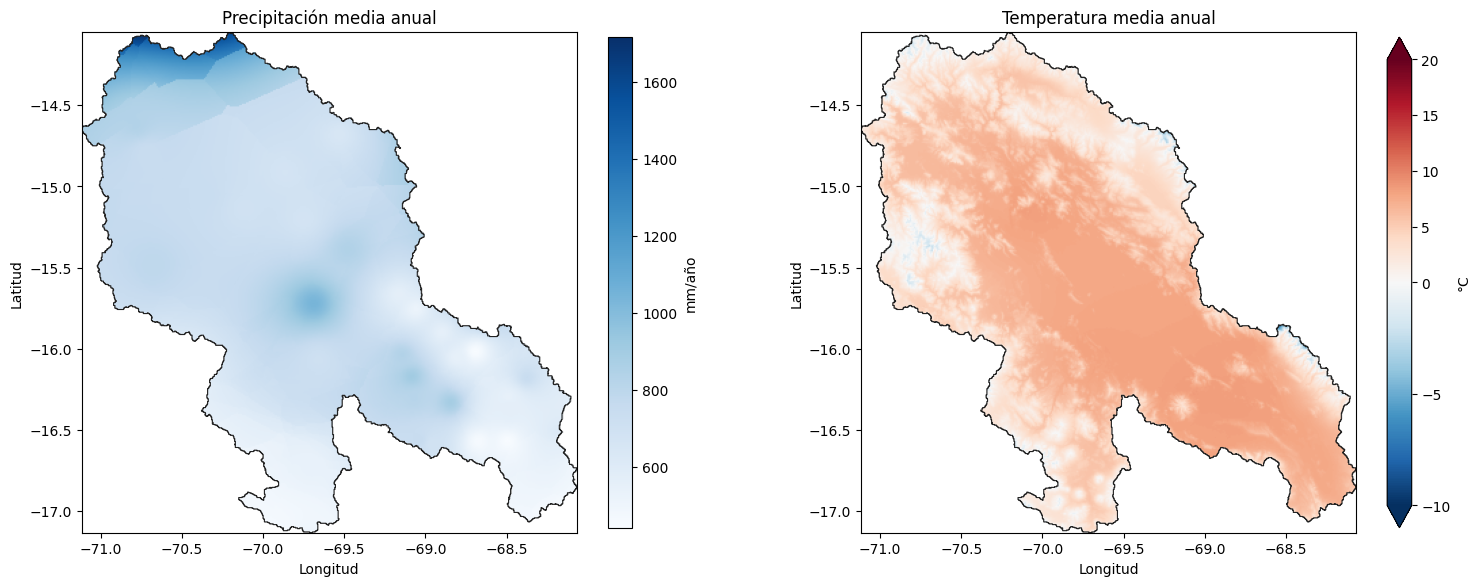



──────────────────────────────────────────────────────────────────────────────────────────
  Climatología mensual de precipitación
──────────────────────────────────────────────────────────────────────────────────────────



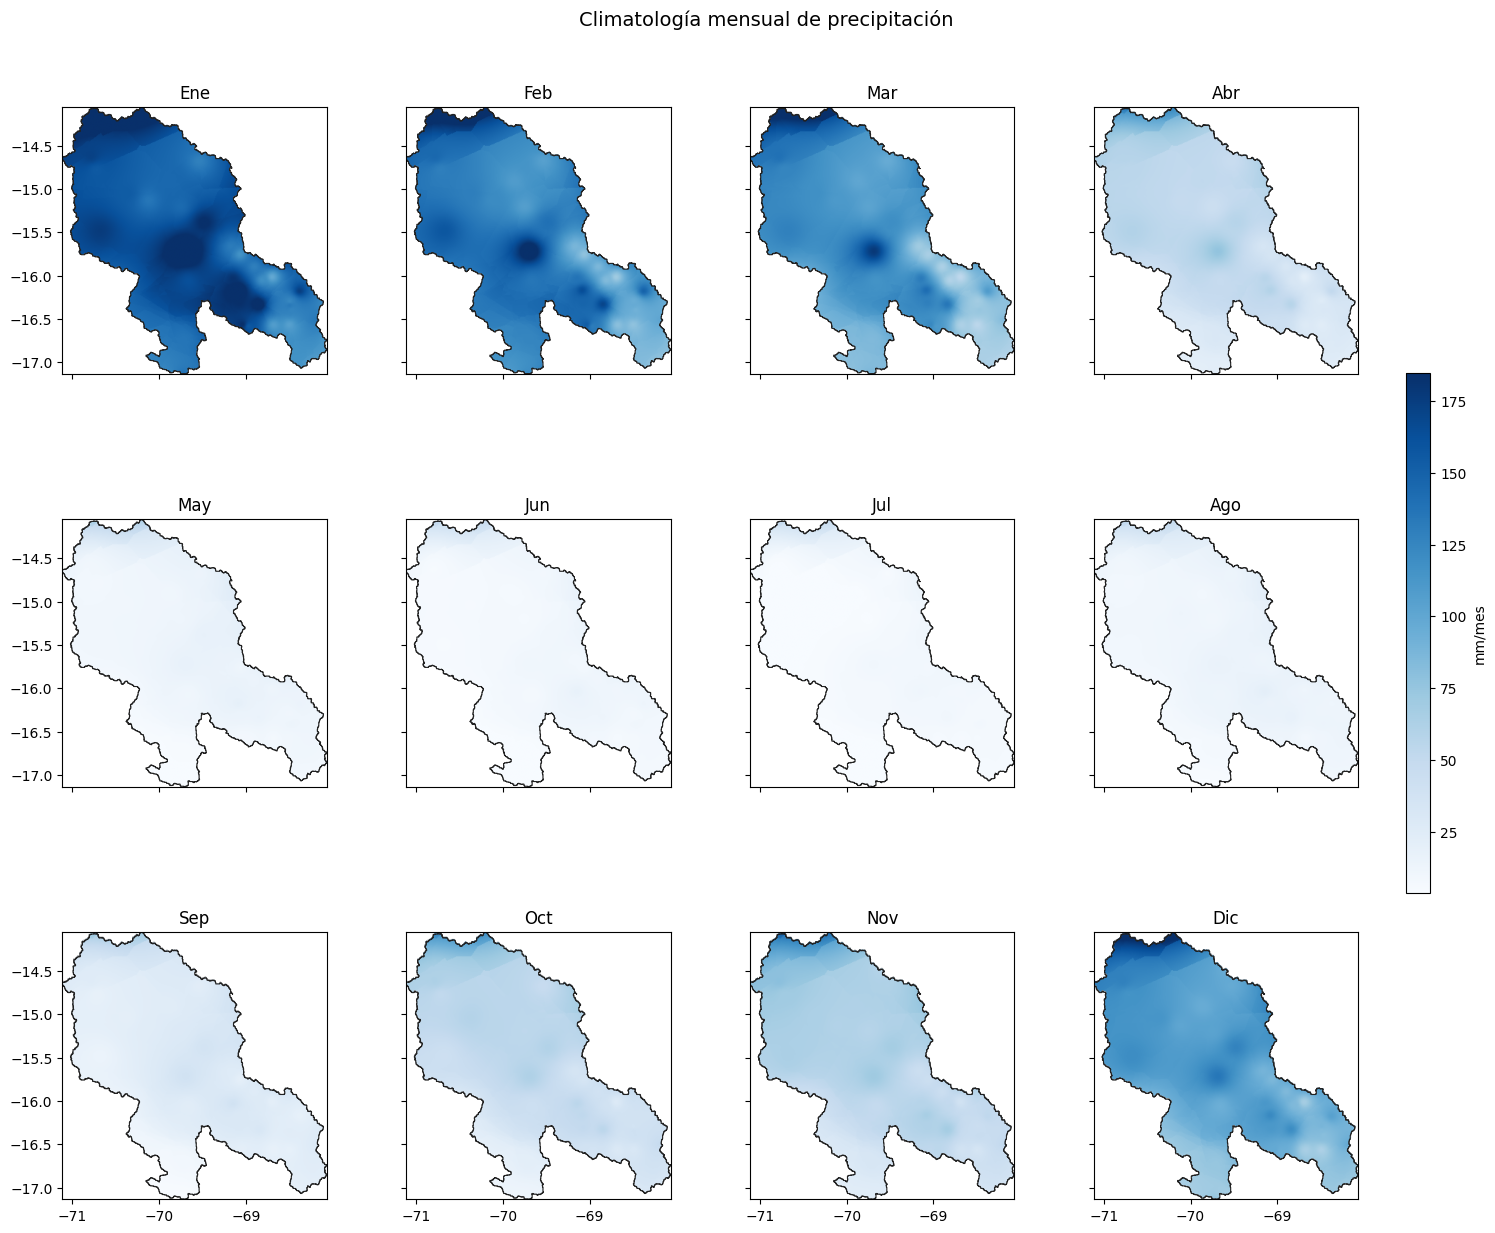



──────────────────────────────────────────────────────────────────────────────────────────
  Climatología mensual de temperatura
──────────────────────────────────────────────────────────────────────────────────────────



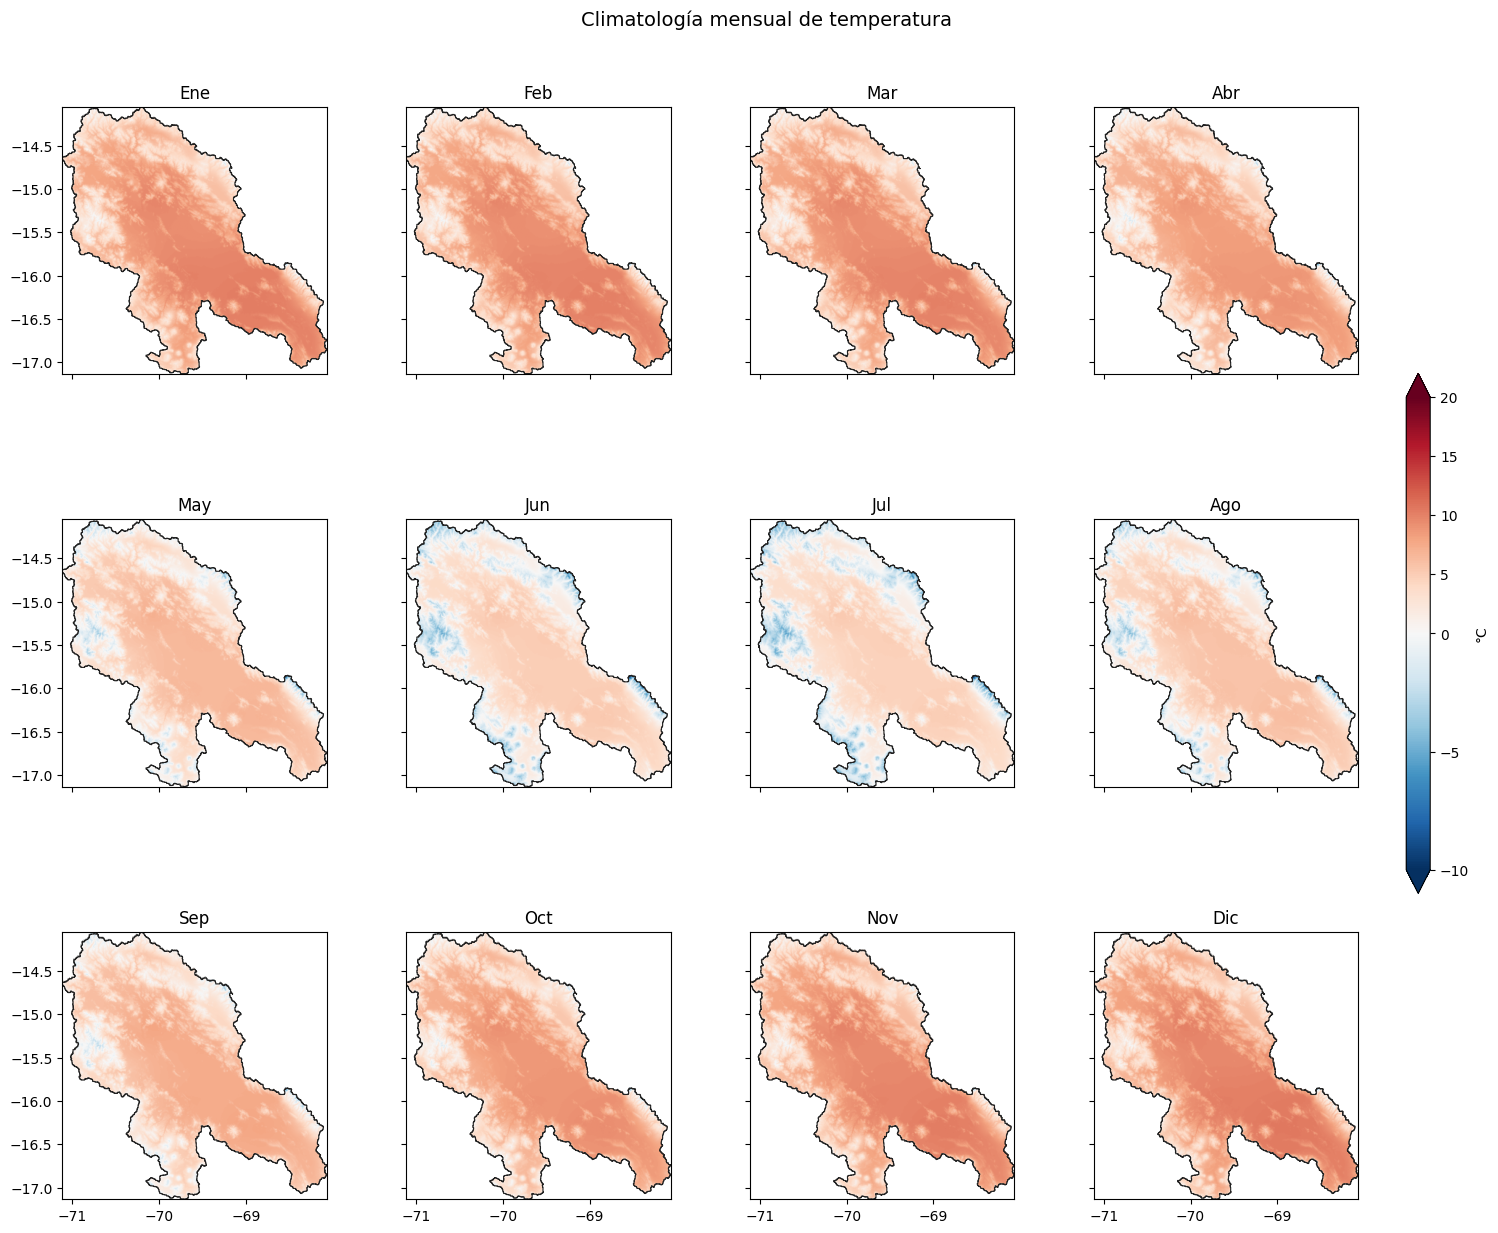



──────────────────────────────────────────────────────────────────────────────────────────
  Series mensuales de la cuenca
──────────────────────────────────────────────────────────────────────────────────────────



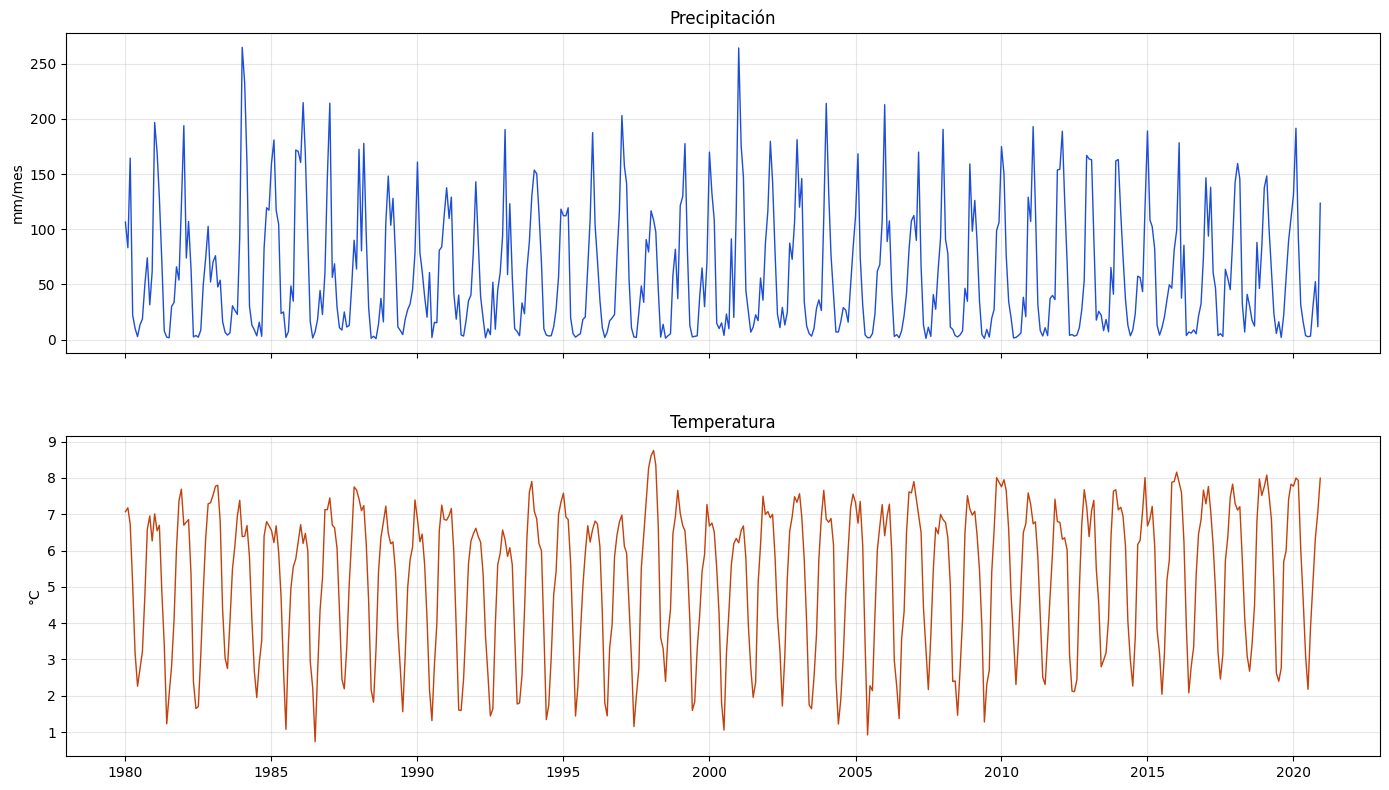



──────────────────────────────────────────────────────────────────────────────────────────
  Climatología de la cuenca
──────────────────────────────────────────────────────────────────────────────────────────



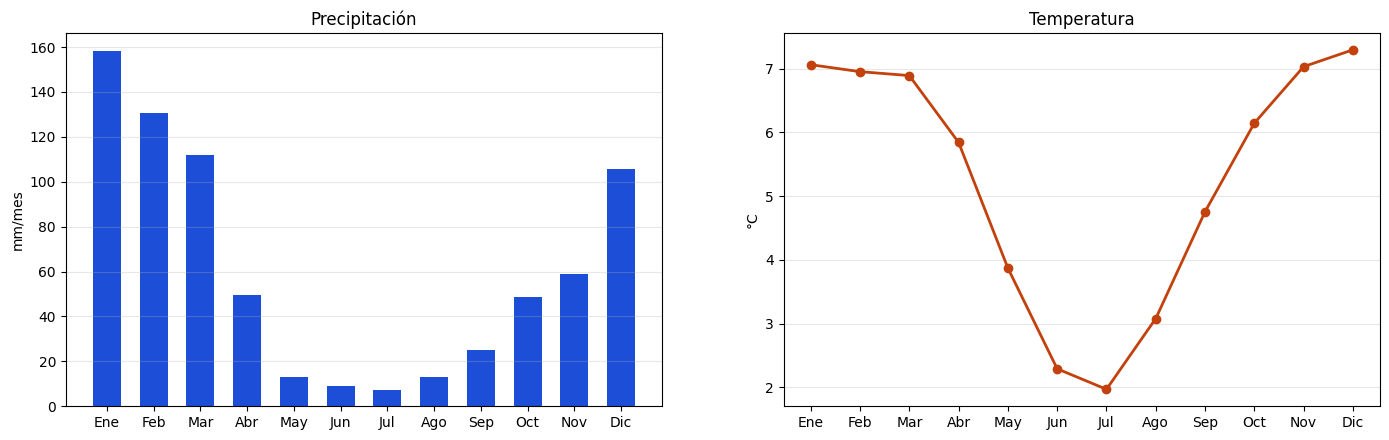



──────────────────────────────────────────────────────────────────────────────────────────
  Temperatura vs. altitud
──────────────────────────────────────────────────────────────────────────────────────────



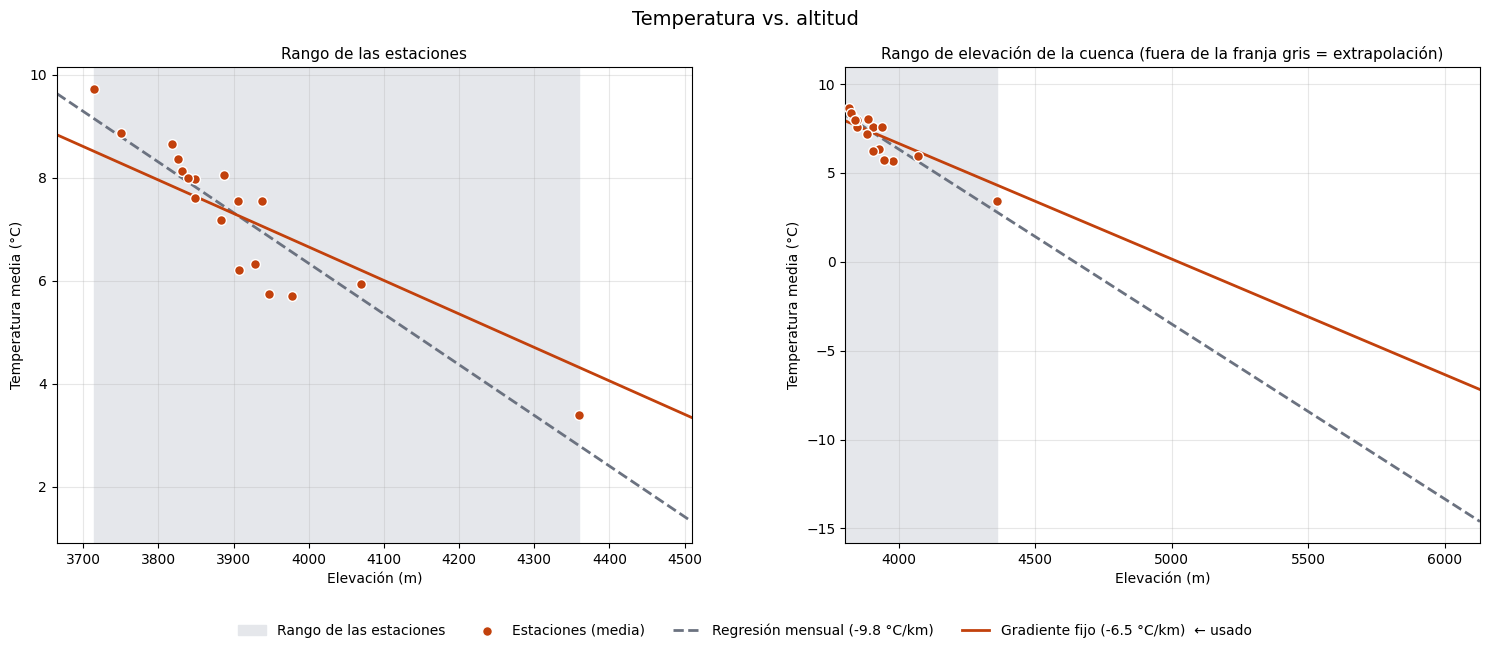



──────────────────────────────────────────────────────────────────────────────────────────
  Resumen
──────────────────────────────────────────────────────────────────────────────────────────

Rango en la cuenca: precipitación anual 441-1717 mm | temperatura media -6.9 a 8.5 °C
Rango en todo el DEM (NetCDF): temperatura media -6.9 a 30.0 °C


In [ ]:
# ---------- Series mensuales promedio de la cuenca (ponderadas por el área de la celda, cos(lat)) ----------
peso = np.cos(np.radians(LAT[en_cuenca]))
def promedio_cuenca(datos):
    x = datos[:, en_cuenca]
    ok = ~np.isnan(x)
    return (np.where(ok, x, 0) * peso).sum(1) / (ok * peso).sum(1)

series = pd.DataFrame({"Fecha": meses.strftime("%Y-%m"), "Anio": meses.year, "Mes": meses.month,
                       f"{VAR_PR}_mm": promedio_cuenca(PR).round(2), f"{VAR_TS}_degC": promedio_cuenca(TS).round(3)})
def separador(titulo):
    """Deja espacio y un título entre un gráfico y el siguiente en la salida de Colab."""
    print("\n\n" + "─" * 90 + f"\n  {titulo}\n" + "─" * 90 + "\n")

series.to_csv(os.path.join(SALIDA, "Series_mensuales_cuenca.csv"), index=False)
separador("Series mensuales promedio de la cuenca")
print("Guardado: Series_mensuales_cuenca.csv"
      + ("" if ARCHIVO_SHAPE else " (sin shape: promedio de toda la extensión del DEM)"))
display(series.head())

# ---------- Mapas medios y climatologías ----------
import warnings
mes_idx = np.asarray(meses.month)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)          # celdas sin dato en el DEM
    pr_anual = np.nanmean(PR, axis=0) * 12
    ts_media = np.nanmean(TS, axis=0)
    clim_pr = np.stack([np.nanmean(PR[mes_idx == m], axis=0) for m in range(1, 13)])
    clim_ts = np.stack([np.nanmean(TS[mes_idx == m], axis=0) for m in range(1, 13)])
nombres_mes = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]

from matplotlib.colors import TwoSlopeNorm, Normalize
# Escala de temperatura fija para todos los mapas (anual y mensuales): frío en azul, 0 °C en blanco, cálido en rojo
CMAP_TS = "RdBu_r"
NORMA_TS = (TwoSlopeNorm(vmin=ESCALA_TEMP[0], vcenter=0, vmax=ESCALA_TEMP[1]) if ESCALA_TEMP[0] < 0 < ESCALA_TEMP[1]
            else Normalize(vmin=ESCALA_TEMP[0], vmax=ESCALA_TEMP[1]))

def mapa(ax, grilla, cmap, titulo, etiqueta, vmin=None, vmax=None, barra=True, norma=None):
    rango = {"norm": norma} if norma is not None else {"vmin": vmin, "vmax": vmax}
    im = ax.imshow(recortar(grilla), extent=ext_recorte, cmap=cmap, origin="upper", **rango)
    dibujar_capas(ax)
    ax.set_xlim(ext_recorte[0], ext_recorte[1]); ax.set_ylim(ext_recorte[2], ext_recorte[3])
    ax.set_title(titulo)
    if barra:
        plt.colorbar(im, ax=ax, shrink=0.8, label=etiqueta, extend="both" if norma is not None else "neither")
    return im

separador("Mapas medios anuales")
fig, axs = plt.subplots(1, 2, figsize=(15, 6.5))
mapa(axs[0], pr_anual, "Blues", "Precipitación media anual", "mm/año")
mapa(axs[1], ts_media, CMAP_TS, "Temperatura media anual", "°C", norma=NORMA_TS)
for ax in axs:
    ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
plt.tight_layout(w_pad=6); plt.savefig(os.path.join(GRAFICOS, "02_mapas_medios_anuales.png"), dpi=200); plt.show()

for clim, cmap, norma, nombre, etiqueta, archivo in (
        (clim_pr, "Blues", None, "precipitación", "mm/mes", "03_climatologia_PR.png"),
        (clim_ts, CMAP_TS, NORMA_TS, "temperatura", "°C", "04_climatologia_TS.png")):
    vals = np.concatenate([recortar(c).ravel() for c in clim])
    vmin, vmax = np.nanpercentile(vals, 1), np.nanpercentile(vals, 99)
    separador(f"Climatología mensual de {nombre}")
    fig, axs = plt.subplots(3, 4, figsize=(16, 13), sharex=True, sharey=True)
    fig.subplots_adjust(left=0.06, right=0.87, bottom=0.05, top=0.92, wspace=0.3, hspace=0.35)
    for m, ax in enumerate(axs.flat):
        im = mapa(ax, clim[m], cmap, nombres_mes[m], etiqueta, vmin, vmax, barra=False, norma=norma)
    fig.colorbar(im, cax=fig.add_axes([0.9, 0.3, 0.015, 0.4]), label=etiqueta,
                 extend="both" if norma is not None else "neither")
    fig.suptitle(f"Climatología mensual de {nombre}", fontsize=14)
    plt.savefig(os.path.join(GRAFICOS, archivo), dpi=150); plt.show()

# ---------- Series de la cuenca ----------
separador("Series mensuales de la cuenca")
fechas = meses.to_timestamp()
fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axs[0].plot(fechas, series[f"{VAR_PR}_mm"], color="#1d4ed8", lw=1)
axs[0].set_ylabel("mm/mes"); axs[0].set_title("Precipitación")
axs[1].plot(fechas, series[f"{VAR_TS}_degC"], color="#c2410c", lw=1)
axs[1].set_ylabel("°C"); axs[1].set_title("Temperatura")
for ax in axs:
    ax.grid(alpha=0.3)
plt.tight_layout(h_pad=4); plt.savefig(os.path.join(GRAFICOS, "05_series_cuenca.png"), dpi=200); plt.show()

separador("Climatología de la cuenca")
clim_cuenca = series.groupby("Mes")[[f"{VAR_PR}_mm", f"{VAR_TS}_degC"]].mean()
fig, axs = plt.subplots(1, 2, figsize=(14, 4.5))
axs[0].bar(nombres_mes, clim_cuenca[f"{VAR_PR}_mm"], color="#1d4ed8", width=0.6)
axs[0].set_ylabel("mm/mes"); axs[0].set_title("Precipitación")
axs[1].plot(nombres_mes, clim_cuenca[f"{VAR_TS}_degC"], color="#c2410c", marker="o", lw=2)
axs[1].set_ylabel("°C"); axs[1].set_title("Temperatura")
for ax in axs:
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout(w_pad=6); plt.savefig(os.path.join(GRAFICOS, "06_climatologia_cuenca.png"), dpi=200); plt.show()

# ---------- Temperatura vs. altitud: estaciones, regresión y gradiente ----------
# Izquierda: zoom al rango de las estaciones. Derecha: todo el rango de elevación de la cuenca (extrapolación).
t_est = mensual_ts[est_ts["Codigo"]].mean().to_numpy()
z_cuenca = (np.nanmin(dem[en_cuenca]), np.nanmax(dem[en_cuenca]))
z_zoom = (min(z_ts.min(), z_cuenca[0]) - 50, z_ts.max() + 150)
a_m, b_m = diag["intercepto_C"].mean(), diag["gradiente_C_por_km"].mean() / 1000
t_ref = np.average(t_est - GRADIENTE_TEMP / 1000 * z_ts)

separador("Temperatura vs. altitud")
fig, axs = plt.subplots(1, 2, figsize=(15, 6.5))
for ax, (z0, z1), titulo in zip(axs, (z_zoom, z_cuenca),
                                ("Rango de las estaciones",
                                 "Rango de elevación de la cuenca (fuera de la franja gris = extrapolación)")):
    zz = np.array([z0, z1])
    ax.axvspan(z_ts.min(), z_ts.max(), color="#e5e7eb", label="Rango de las estaciones")
    ax.scatter(z_ts, t_est, s=50, c="#c2410c", edgecolors="white", zorder=3, label="Estaciones (media)")
    ax.plot(zz, a_m + b_m * zz, color="#6b7280", lw=2, ls="--",
            label=f"Regresión mensual ({b_m * 1000:.1f} °C/km)" + ("  ← usada" if METODO_TEMP == "regresion" else ""))
    ax.plot(zz, t_ref + GRADIENTE_TEMP / 1000 * zz, color="#c2410c", lw=2,
            label=f"Gradiente fijo ({GRADIENTE_TEMP} °C/km)" + ("  ← usado" if METODO_TEMP == "gradiente_fijo" else ""))
    ax.set_xlim(z0, z1)
    ax.set_xlabel("Elevación (m)"); ax.set_ylabel("Temperatura media (°C)")
    ax.set_title(titulo, fontsize=11); ax.grid(alpha=0.3)
fig.legend(*axs[0].get_legend_handles_labels(), loc="lower center", ncol=4, frameon=False)
fig.suptitle("Temperatura vs. altitud", fontsize=14)
plt.tight_layout(w_pad=6, rect=(0, 0.07, 1, 1)); plt.savefig(os.path.join(GRAFICOS, "07_temperatura_vs_altitud.png"), dpi=200); plt.show()

separador("Resumen")
print(f"Rango en la cuenca: precipitación anual {np.nanmin(recortar(pr_anual)):.0f}-{np.nanmax(recortar(pr_anual)):.0f} mm | "
      f"temperatura media {np.nanmin(recortar(ts_media)):.1f} a {np.nanmax(recortar(ts_media)):.1f} °C")
print(f"Rango en todo el DEM (NetCDF): temperatura media {np.nanmin(ts_media):.1f} a {np.nanmax(ts_media):.1f} °C")

## Paso 10. Validación cruzada

Precipitación: combinaciones de `POTENCIA` y `VECINOS`. Temperatura: regresión frente a gradiente fijo con distintos valores de $\Gamma$. Un menor RMSE indica un mejor desempeño.

In [ ]:
def matriz_distancias(lon, lat):
    if DISTANCIA == "geodesica":
        c = _cartesianas(lon, lat)
        cuerda = np.sqrt(((c[:, None, :] - c[None, :, :]) ** 2).sum(-1))
        return 2 * R_TIERRA_KM * np.arcsin(np.clip(cuerda / 2, 0, 1))
    return np.hypot(lon[:, None] - lon[None, :], lat[:, None] - lat[None, :])

def metricas(o, p):
    r = np.corrcoef(o, p)[0, 1]
    out = {"RMSE": np.sqrt(np.mean((p - o) ** 2)), "MAE": np.mean(np.abs(p - o)), "Sesgo": np.mean(p - o), "r": r}
    if o.mean() > 0:
        out["KGE"] = 1 - np.sqrt((r - 1) ** 2 + (p.std() / o.std() - 1) ** 2 + (p.mean() / o.mean() - 1) ** 2)
    return out

def idw_loo(V, D, s, potencia, vecinos):
    """Estimación IDW en la estación s con las demás, todos los meses."""
    otros = np.delete(np.arange(V.shape[1]), s)
    orden = otros[np.argsort(D[s, otros], kind="stable")]
    d = np.maximum(D[s, orden], 1e-10)
    vals = V[:, orden]
    disp = ~np.isnan(vals)
    w = np.where(disp & (np.cumsum(disp, axis=1) <= vecinos), 1.0 / d ** potencia, 0.0)
    sw = w.sum(axis=1)
    return (w * np.nan_to_num(vals)).sum(axis=1) / np.where(sw > 0, sw, np.nan)

def cv_precipitacion(potencia, vecinos):
    D = matriz_distancias(est_pr["Lon"].to_numpy(float), est_pr["Lat"].to_numpy(float))
    obs, pre = [], []
    for s in np.where(dentro_pr)[0]:
        p = idw_loo(V_pr, D, s, potencia, vecinos)
        ok = ~np.isnan(V_pr[:, s]) & ~np.isnan(p)
        obs.append(V_pr[ok, s]); pre.append(p[ok])
    return metricas(np.concatenate(obs), np.concatenate(pre))

def cv_temperatura(metodo, gradiente=None):
    D = matriz_distancias(est_ts["Lon"].to_numpy(float), est_ts["Lat"].to_numpy(float))
    obs, pre = [], []
    for s in np.where(dentro_ts)[0]:
        if metodo == "gradiente_fijo":
            G = gradiente / 1000
            p = idw_loo(V_ts - G * z_ts[None, :], D, s, POTENCIA, VECINOS) + G * z_ts[s]
        else:
            otros = np.delete(np.arange(V_ts.shape[1]), s)
            p = np.full(nt, np.nan)
            for i, v in enumerate(V_ts[:, otros]):
                ok = ~np.isnan(v)
                if ok.sum() >= MIN_ESTACIONES_REG:
                    a, b, _ = regresion_altitud(z_ts[otros][ok], v[ok])
                    p[i] = a + b * z_ts[s]
        ok = ~np.isnan(V_ts[:, s]) & ~np.isnan(p)
        obs.append(V_ts[ok, s]); pre.append(p[ok])
    return metricas(np.concatenate(obs), np.concatenate(pre))

if EJECUTAR_VALIDACION:
    cv_pr = pd.DataFrame([{"POTENCIA": p, "VECINOS": k, **cv_precipitacion(p, k)}
                          for p in [1, 1.5, 2, 2.5, 3] for k in [5, 8, 10, 15]]).sort_values("RMSE")
    cv_pr.round(3).to_csv(os.path.join(SALIDA, "validacion_cruzada_PR.csv"), index=False)
    print("PRECIPITACIÓN (mm/mes) — mejores combinaciones:")
    display(cv_pr.head(5).round(3))

    filas_ts = [{"Metodo": "regresion", "Gradiente_C_km": np.nan, **cv_temperatura("regresion")}]
    filas_ts += [{"Metodo": "gradiente_fijo", "Gradiente_C_km": g, **cv_temperatura("gradiente_fijo", g)}
                 for g in sorted({-5.5, -6.0, -6.5, -7.0, -7.5, -8.5, float(GRADIENTE_TEMP)})]
    cv_ts = pd.DataFrame(filas_ts).sort_values("RMSE")
    cv_ts.round(3).to_csv(os.path.join(SALIDA, "validacion_cruzada_TS.csv"), index=False)
    print("\nTEMPERATURA (°C):")
    display(cv_ts.round(3))
    print("Nota: la validación solo evalúa el rango de altitud de las estaciones; fuera de ese rango "
          "(zonas bajas o nevados) un gradiente físico (~ -6,5 °C/km) extrapola mejor que una regresión muy pronunciada.")

PRECIPITACIÓN (mm/mes) — mejores combinaciones:


,POTENCIA,VECINOS,RMSE,MAE,Sesgo,r,KGE
15,2.5,15,32.349,18.668,-2.988,0.872,0.796
11,2.0,15,32.409,18.840,-2.626,0.872,0.793
19,3.0,15,32.486,18.682,-3.194,0.871,0.799
13,2.5,8,32.604,18.755,-3.165,0.870,0.800
9,2.0,8,32.639,18.842,-3.064,0.870,0.795



TEMPERATURA (°C):


,Metodo,Gradiente_C_km,RMSE,MAE,Sesgo,r,KGE
3,gradiente_fijo,-7.0,0.620,0.502,0.082,0.970,0.955
2,gradiente_fijo,-7.5,0.623,0.502,0.083,0.969,0.962
4,gradiente_fijo,-6.5,0.626,0.517,0.080,0.969,0.946
5,gradiente_fijo,-6.0,0.642,0.536,0.079,0.967,0.937
1,gradiente_fijo,-8.5,0.657,0.543,0.087,0.967,0.963
6,gradiente_fijo,-5.5,0.666,0.555,0.077,0.965,0.928
0,regresion,NaN,0.963,0.743,0.068,0.942,0.863


Nota: la validación solo evalúa el rango de altitud de las estaciones; fuera de ese rango (zonas bajas o nevados) un gradiente físico (~ -6,5 °C/km) extrapola mejor que una regresión muy pronunciada.


## Paso 11. Descarga de resultados

El `.zip` contiene el NetCDF, las series mensuales por estación y de la cuenca, los resultados de la validación cruzada, los parámetros utilizados (`parametros.json`) y los gráficos.

In [ ]:
print("Contenido de", CARPETA_SALIDA)
for raiz, _, archivos in os.walk(SALIDA):
    for a in sorted(archivos):
        if raiz.endswith("_ASCII"):
            continue
        ruta = os.path.join(raiz, a)
        print(f"  {os.path.relpath(ruta, SALIDA):45s} {os.path.getsize(ruta) / 1e6:8.1f} MB")

if EN_COLAB and not USAR_DRIVE:
    from google.colab import files
    zip_salida = shutil.make_archive(os.path.join("/content", CARPETA_SALIDA), "zip", CARPETA_PROYECTO, CARPETA_SALIDA)
    print(f"\nDescargando {os.path.basename(zip_salida)} ({os.path.getsize(zip_salida) / 1e6:.0f} MB)...")
    files.download(zip_salida)

Contenido de Resultados_Clima_Titicaca
  Clima_Titicaca_1980-2020.nc                      557.9 MB
  PR_mensual_estaciones.csv                          0.2 MB
  Series_mensuales_cuenca.csv                        0.0 MB
  TS_mensual_estaciones.csv                          0.0 MB
  TS_regresion_altitud_mensual.csv                   0.0 MB
  parametros.json                                    0.0 MB
  validacion_cruzada_PR.csv                          0.0 MB
  validacion_cruzada_TS.csv                          0.0 MB
  graficos/01_DEM_estaciones.png                     0.3 MB
  graficos/02_mapas_medios_anuales.png               0.8 MB
  graficos/03_climatologia_PR.png                    0.7 MB
  graficos/04_climatologia_TS.png                    1.5 MB
  graficos/05_series_cuenca.png                      0.5 MB
  graficos/06_climatologia_cuenca.png                0.1 MB
  graficos/07_temperatura_vs_altitud.png             0.2 MB
  graficos/netcdf_mapas_2010-01.png                  1.5 MB
 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Parte VIII. Aplicación en WEAP y actividades

## 8.1 Verificación de los resultados

Antes de utilizar el NetCDF en la modelación, se recomienda contrastar los resultados con estudios y productos climáticos recientes de la región (por ejemplo, el *Balance Hídrico de Bolivia 1980–2020* y productos grillados nacionales o satelitales), así como validarlos con información de campo y con estaciones que no hayan intervenido en la interpolación.

## 8.2 Incorporación del NetCDF en WEAP

1. En el modo **Catchment Delineation**, active **Load Climate Data** y seleccione **User-specified file (NetCDF format)**.
2. Seleccione `Clima_Titicaca_1980-2020.nc` y revise la resolución, la extensión y las variables.
3. Elija el método de cuenca y vincule `Pcp` con la precipitación y `Ts` con la temperatura.
4. Defina los años de datos y cree las cuencas: WEAP genera los CSV en la carpeta `ClimateData` y las expresiones `ReadFromFile` por banda de elevación.

El método de humedad del suelo requiere además otras variables climáticas (por ejemplo, humedad relativa y viento), que deben obtenerse de otras fuentes. Los métodos MABIA y *Plant Growth* requieren datos diarios.

## 8.3 Actividades propuestas

1. Modifique `POTENCIA` y `VECINOS` y compare los mapas y la validación cruzada.
2. Cambie `GRADIENTE_TEMP` a −7,6 °C/km y compare la temperatura de la cuenca y el RMSE con los obtenidos con −6,5 °C/km.
3. Ejecute con `METODO_TEMP = "regresion"` y analice los extremos de temperatura en zonas bajas y cumbres.
4. Excluya las estaciones amazónicas (`EXCLUIR_ESTACIONES = ["X100030", "X100114", "X113119"]`) y evalúe el efecto en el norte de la cuenca.

## 8.4 Conclusiones

- La interpolación es el puente entre las observaciones puntuales y las forzantes que requiere WEAP; ningún método es universalmente superior y la elección debe sustentarse en la validación cruzada y en la coherencia física.
- En zonas de montaña, la temperatura debe interpolarse incorporando la altitud.
- Un NetCDF con convenciones CF permite entregar los resultados en un único archivo que WEAP incorpora directamente mediante la delimitación de cuencas.

## Referencias

- Daly, C., Neilson, R. P. y Phillips, D. L. (1994). A statistical-topographic model for mapping climatological precipitation over mountainous terrain. *Journal of Applied Meteorology*, 33(2), 140–158.
- Goovaerts, P. (2000). Geostatistical approaches for incorporating elevation into the spatial interpolation of rainfall. *Journal of Hydrology*, 228(1–2), 113–129.
- Gupta, H. V., Kling, H., Yilmaz, K. K. y Martinez, G. F. (2009). Decomposition of the mean squared error and NSE performance criteria. *Journal of Hydrology*, 377(1–2), 80–91.
- Hutchinson, M. F. (1995). Interpolating mean rainfall using thin plate smoothing splines. *International Journal of Geographical Information Systems*, 9(4), 385–403.
- IRD (1992). Climatology and hydrology (capítulo IV). En Dejoux, C. e Iltis, A. (eds.), *Lake Titicaca: A Synthesis of Limnological Knowledge*.
- Isaaks, E. H. y Srivastava, R. M. (1989). *An Introduction to Applied Geostatistics*. Oxford University Press.
- MMAyA y SEI (2024). *Balance Hídrico de Bolivia 1980–2020*. La Paz, Bolivia. https://doi.org/10.5281/zenodo.10850934
- SEI. WEAP: *Automatic Catchment Delineation* (ayuda en línea). https://weap.sei.org/WebHelp/Catchment_Delineation.htm
- Shepard, D. (1968). A two-dimensional interpolation function for irregularly-spaced data. *Proceedings of the 23rd ACM National Conference*, 517–524.
- Thiessen, A. H. (1911). Precipitation averages for large areas. *Monthly Weather Review*, 39(7), 1082–1084.